**实验目标：**

通过本实验，你将深入了解和实践说话人识别技术，并掌握利用声音特征进行有效说话人识别的基本方法，了解不同特征和模型对识别准确率的影响。

实验的核心目标是使用TIMIT数据集来训练一个说话人识别系统，涵盖数据预处理、特征提取、模型训练和评估等关键步骤。


**实验方法：**

**1. 数据预处理和划分(可选)：**
  - 数据集下载：
    - 大陆访问url: https://yun.139.com/shareweb/#/w/i/2ur4mcv5Y4qc7  提取码:yn8x（4月27日18点前可访问）
    - 谷歌访问url: https://drive.google.com/file/d/180mSIiXN9RVDV2Xn1xcWNkMRm5J5MjN4/view?usp=sharing
  - 为了方便大家，我们提供了划分好的TIMIT数据集结构，当然你也可以根据需求自行划分该数据集。
  - 为简化难度，我们排除了SA的两个方言句子，并在剩余的8个句子中选取了SX的5个句子和SI的1个句子作为训练集，SI的另外2个句子作为测试集。
  - 该链接下载的数据集只保留了音频文件，完整数据集（包含音频对应文本、标注等信息）可参见备注链接下载。
  
**2. 特征提取：**
  - 学习并实现包括但不限于MFCC特征等特征的提取，探索声音信号的频率和时间特性。
  - 鼓励尝试和比较其他特征提取方法，例如LPCC或声谱图特征，以理解不同特征对识别性能的影响。
  
**3. 模型选择和训练：**
  - 探索并选择适合的分类器和模型进行说话人识别，如GMM、Softmax分类器或深度学习模型。
  - 实现模型训练流程，使用训练集数据训练模型。
  
**4. 评估和分析：**
  - 使用准确率作为主要的评价指标在测试集上评估模型性能。
  - 对比不同特征和模型的性能，分析其对说话人识别准确率的影响。
  - 可视化不同模型的识别结果和错误率，讨论可能的改进方法。

**实验要求：**
  - 1.选择并实现至少一种特征的提取，并鼓励尝试其他特征提取方法。
  - 2.选择并实现至少一种分类器或模型进行说话人识别，并使用准确率评估指标评估其性能。
  - 3.通过实验对比、分析和可视化，撰写详细的实验报告，包括实验目的、实验方法、结果分析和结论。
  - 4.实验报告应以清晰、逻辑性强的形式呈现，图表和结果应清楚明了。

**其他说明：**
  - 实验的最终打分环节会看识别性能，会对原理和实现代码部分做抽查提问，综合评定成绩。
  - 我们**鼓励做原创性探索**，即使性能不是很好，但有创新性、有价值、有意义的探索和尝试会有额外加分。

### 实验整体流程

本实验基于 TIMIT 数据集，完成闭集说话人识别任务（462 位说话人）。实验流程如下：

1. **数据预处理**：加载 TIMIT 数据集（NIST SPHERE 格式），建立文件路径与说话人标签的映射，划分训练集（2772 条）和测试集（924 条）。

2. **特征提取**：每位成员独立实现一种声学特征——MFCC（Mel 频率倒谱系数）、LPCC（线性预测倒谱系数）和 Fbank（Log Mel 滤波器组能量），分别从频谱感知、声道结构和原始 Mel 频谱三个角度刻画语音信号。

3. **模型训练**：针对各特征选择合适的分类模型——MFCC+GMM、LPCC+GMM/Softmax（含 LPCC+MFCC 特征融合实验）、Fbank+GMM/SVM，涵盖生成式模型与判别式模型。

4. **模型评估**：在测试集上计算说话人识别准确率，横向对比不同特征-模型组合的性能。

5. **分析与可视化**：通过混淆矩阵、t-SNE 特征分布图等手段分析模型表现，讨论各特征与模型的优劣势。

6. **结果讨论**：总结实验发现，分析不同方案的性能差异及原因，提出改进方向。

### 小组成员分工

| 姓名 | 学号 | 负责内容 |
|------|------|----------|
| 黄艺平 | 2023212179 | MFCC 特征提取 + GMM 模型（特征提取 §3.1、模型训练 §4.1、评估 §5.1、分析 §6.1、讨论 §7.1） |
| 张笑 | 2023212062 | LPCC 特征提取 + GMM/Softmax 模型 + LPCC×MFCC 特征融合（特征提取 §3.2、模型训练 §4.2、评估 §5.2、分析 §6.2、讨论 §7.2） |
| 李思婷 | 2023212061 | Fbank 特征提取 + GMM/SVM 模型（特征提取 §3.3、模型训练 §4.3、评估 §5.3、分析 §6.3、讨论 §7.3） |


## 1. 实验准备

In [2]:
# 需要安装的包（在终端运行）：
# uv pip install librosa soundfile scikit-learn torch torchaudio matplotlib seaborn

import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa # 一个python的音频分析库，可以加载.wav文件，提取MFCC特征
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix
import torch
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings('ignore')

print("所有库导入成功")
print(f"PyTorch版本: {torch.__version__}")
print(f"GPU可用: {torch.cuda.is_available()}")

所有库导入成功
PyTorch版本: 2.2.2+cu121
GPU可用: True


In [3]:
# 验证torch安装
import torch
print(torch.__version__)          # 应该显示 2.x.x+cu121 而不是 +cpu
print(torch.cuda.is_available())  # True
print(torch.cuda.get_device_name(0))  # 显示你的 GPU 型号

2.2.2+cu121
True
NVIDIA A800 80GB PCIe


## 2. 数据预处理(加载数据集)

In [ ]:
# 数据集基本信息如下
# 方言地区：DR1～DR8
# 性别：F/M
# 说话者ID：3个大写字母+1个阿拉伯数字
# 句子ID：句子类型（SA/SI/SX）+编号
# 详细介绍参见 https://blog.csdn.net/qq_39373179/article/details/103788208

# 上述链接下载的数据集已经
# TrainDir = "Dataset\TRAIN"
# TestDir = "Dataset\TEST"
## 请在这里写代码加载我们划分好的TIMIT训练集和测试集。或者原始完整版数据集。

### 2.1 提取train_info.json和test_info.json中需要的.wav文件

提取后的文件保存在TRAIN_ORG/TEST_ORG文件夹下，按照说话人id命名，包含.wav文件

In [ ]:
import os
import json
import shutil

# 两个_info.json都放在TIMIT/TRAIN下面
TrainDir = "TIMIT/TRAIN"
# 测试数据也是在原本的训练数据中取得，同一个说话人去除SA后还有8条音频，6条训练，2条测试
TestDir  = "TIMIT/TRAIN"

# 重组后的特征存放根目录
TrainOrg = "TIMIT/TRAIN_ORG"   # 按说话人重组后的训练集音频
TestOrg  = "TIMIT/TEST_ORG"    # 按说话人重组后的测试集音频

def reorganize_by_speaker(info_list, src_base_dir, dst_base_dir):
    """
    把 info_list 中涉及的 .wav 按说话人重组到 dst_base_dir/<speaker_id>/ 下
    目标结构：
        dst_base_dir/
            CJF0/
                SI648.wav
                SX127.wav
                ...
            DAB0/
                ...
    """
    os.makedirs(dst_base_dir, exist_ok=True)
    for item in info_list:
        # 去掉文件名末尾的下划线
        name, ext = os.path.splitext(os.path.basename(item["filepath"]))
        filename = name.rstrip("_") + ext
        
        # 用修正后的文件名拼源路径
        src_dir  = os.path.join(src_base_dir, os.path.dirname(item["filepath"]))
        src_path = os.path.join(src_dir, filename)
        
        spk_dir  = os.path.join(dst_base_dir, item["speaker_id"])
        os.makedirs(spk_dir, exist_ok=True)
        dst_path = os.path.join(spk_dir, filename)
        
        if not os.path.exists(dst_path):
            shutil.copy2(src_path, dst_path)

with open(os.path.join(TrainDir, "train_info.json"), encoding="utf-8") as f:
    train_info = json.load(f)
with open(os.path.join(TestDir, "test_info.json"), encoding="utf-8") as f:
    test_info = json.load(f)

print("重组训练集...")
reorganize_by_speaker(train_info, TrainDir, TrainOrg)
print("重组测试集...")
reorganize_by_speaker(test_info,  TestDir,  TestOrg)
print("重组完成，目录结构示例：")
for spk in sorted(os.listdir(TrainOrg))[:3]:
    files = os.listdir(os.path.join(TrainOrg, spk))
    print(f"  {TrainOrg}/{spk}/  →  {files}")

重组测试集...
重组完成，目录结构示例：
  TIMIT/TRAIN_ORG/ABC0/  →  ['SI781.wav', 'SX151.wav', 'SX241.wav', 'SX331.wav', 'SX421.wav', 'SX61.wav']
  TIMIT/TRAIN_ORG/ADC0/  →  ['SI737.wav', 'SX107.wav', 'SX17.wav', 'SX197.wav', 'SX287.wav', 'SX377.wav']
  TIMIT/TRAIN_ORG/ADD0/  →  ['SI538.wav', 'SX178.wav', 'SX268.wav', 'SX358.wav', 'SX448.wav', 'SX88.wav']


PS: 定义划分后的目录，避免重复划分

In [4]:
TrainOrg = "../TRAIN_ORG"
TestOrg = "../TEST_ORG"

### 2.2 统计音频帧长，确定max_len，方便提取时序特征时设定max_len

遍历所有训练集音频，统计每个文件提取 MFCC 后的时间帧数，帮助决定时序特征提取时 max_len 应该设多少合理，在深度学习模型中可以用到

统计训练集帧长（需要一点时间）...
帧数统计（训练集）:
  最小值: 29
  最大值: 215
  均值:   95.2
  中位数: 91.0
  90%分位: 131.0
  95%分位: 144.0
  99%分位: 165.0


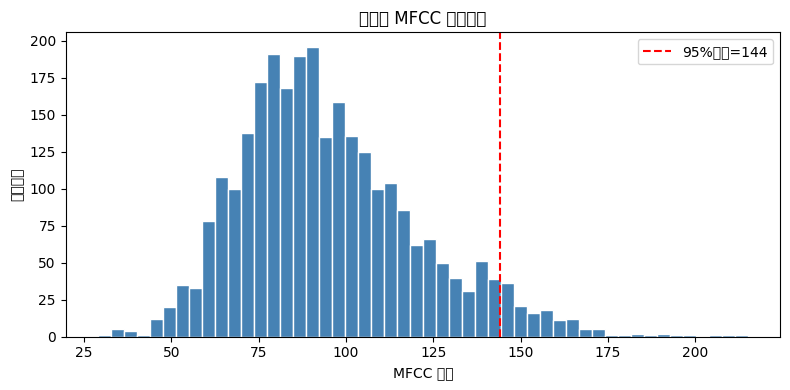


建议 max_len = 144（覆盖95%的句子）


In [11]:
import librosa
import numpy as np
import matplotlib.pyplot as plt

def stat_frame_lengths(org_dir, n_mfcc=40, sr=16000):
    """
    遍历 org_dir 下所有 .wav，统计 MFCC 帧数分布
    帮助决定 max_len 的合理取值
    """
    frame_lens = []
    for spk in os.listdir(org_dir):
        spk_dir = os.path.join(org_dir, spk)
        if not os.path.isdir(spk_dir):
            continue
        for fname in os.listdir(spk_dir):
            if not fname.endswith(".wav"):
                continue
            path = os.path.join(spk_dir, fname)
            y, _ = librosa.load(path, sr=sr)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
            frame_lens.append(mfcc.shape[1])    # 记录该文件的帧数
    return np.array(frame_lens)

print("统计训练集帧长（需要一点时间）...")
frame_lens = stat_frame_lengths(TrainOrg)

print(f"帧数统计（训练集）:")
print(f"  最小值: {frame_lens.min()}")
print(f"  最大值: {frame_lens.max()}")
print(f"  均值:   {frame_lens.mean():.1f}")
print(f"  中位数: {np.median(frame_lens):.1f}")
print(f"  90%分位: {np.percentile(frame_lens, 90):.1f}")
print(f"  95%分位: {np.percentile(frame_lens, 95):.1f}")
print(f"  99%分位: {np.percentile(frame_lens, 99):.1f}")

# 可视化帧长分布
plt.figure(figsize=(8, 4))
plt.hist(frame_lens, bins=50, color='steelblue', edgecolor='white')
plt.axvline(np.percentile(frame_lens, 95), color='red',
            linestyle='--', label=f"95%分位={np.percentile(frame_lens,95):.0f}")
plt.xlabel("MFCC 帧数")
plt.ylabel("音频数量")
plt.title("训练集 MFCC 帧长分布")
plt.legend()
plt.tight_layout()
plt.show()

# 建议的 max_len：取 95% 分位（覆盖绝大多数句子，截断极少数）
MAX_LEN = int(np.percentile(frame_lens, 95))
print(f"\n建议 max_len = {MAX_LEN}（覆盖95%的句子）")

### 2.3 建立(filepath, speaker_id) 列表，建立 说话人ID-整数 映射

列表在构建dataloader时可以用到，保存为train_samples和test_samples；le为labelencoder，在数据集构建、评估模型时可以用到

In [5]:
from sklearn.preprocessing import LabelEncoder

# ============================================================
# 从重组后的目录直接扫描，建立 (filepath, speaker_id) 列表
# ============================================================

def scan_org_dir(org_dir):
    """
    扫描 org_dir/<speaker_id>/*.wav，返回 (filepath, speaker_id) 列表
    标签直接来自文件夹名，不再依赖 json
    """
    samples = []
    for spk in sorted(os.listdir(org_dir)):          # 排序保证可复现
        spk_dir = os.path.join(org_dir, spk)
        if not os.path.isdir(spk_dir):
            continue
        for fname in sorted(os.listdir(spk_dir)):
            if fname.endswith(".wav"):
                samples.append({
                    "filepath":   os.path.join(spk_dir, fname),
                    "speaker_id": spk
                })
    return samples

train_samples = scan_org_dir(TrainOrg)
test_samples  = scan_org_dir(TestOrg)

print(f"训练集样本数: {len(train_samples)}")
print(f"测试集样本数: {len(test_samples)}")

# LabelEncoder 只用训练集说话人 fit
all_speakers = sorted(set(s["speaker_id"] for s in train_samples))
le = LabelEncoder()
le.fit(all_speakers)
NUM_CLASSES = len(all_speakers)

# 打印映射关系
mapping = {spk: idx for idx, spk in enumerate(le.classes_)}
print(f"说话人 → 标签映射（共 {NUM_CLASSES} 人，展示前10条）：")
for spk, idx in list(mapping.items())[:10]:
    print(f"  {spk} → {idx}")


训练集样本数: 2772
测试集样本数: 924
说话人 → 标签映射（共 462 人，展示前10条）：
  ABC0 → 0
  ADC0 → 1
  ADD0 → 2
  AEB0 → 3
  AEM0 → 4
  AEO0 → 5
  AFM0 → 6
  AJP0 → 7
  AJW0 → 8
  AKB0 → 9


### 2.4 构建数据集，先运行 3.特征提取，因为数据集里面有特征

#### 2.4.1 MFCC-GMM dataloader

提取统计特征

In [24]:
# ============================================================
# 批量构建数据集（离线预提取，训练时直接读数组）
# ============================================================

def build_dataset(samples, label_encoder):
    """
    samples: scan_org_dir() 的返回值，每条含 filepath 和 speaker_id
    mode:    "mean" → 统计特征 (N, 80)，供传统模型使用
    """
    X, y = [], []
    for item in samples:
        feat  = extract_mfcc_mean(item["filepath"]) 
        label = label_encoder.transform([item["speaker_id"]])[0]
        X.append(feat)
        y.append(label)
    return np.array(X), np.array(y)

print("提取统计特征（传统模型用）...")
X_train_flat, y_train = build_dataset(train_samples, le)
X_test_flat,  y_test  = build_dataset(test_samples,  le)
print(f"  X_train_flat shape: {X_train_flat.shape}")
print(f"  样本示例: 标签={y_train[0]}({le.inverse_transform([y_train[0]])[0]}), 特征前8维={X_train_flat[0][:8].round(2)}")

提取统计特征（传统模型用）...
  X_train_flat shape: (2772, 80)
  样本示例: 标签=0(ABC0), 特征前8维=[-3.3112e+02  8.6850e+01 -2.5210e+01 -1.7000e-01 -2.4810e+01 -1.2890e+01
 -2.2370e+01 -2.2780e+01]


提取帧特征

In [25]:
def build_dataset_frames(samples, label_encoder):
    """
    帧级别特征，每帧单独作为一条样本
    同一句话的所有帧共享同一个说话人标签
    """
    X, y = [], []
    for item in samples:
        frames = extract_mfcc_frames(item["filepath"])  # (帧数, 40)
        label  = label_encoder.transform([item["speaker_id"]])[0]
        X.append(frames)
        y.extend([label] * len(frames))   # 每帧都贴上同一个标签
    return np.vstack(X), np.array(y)      # X: (总帧数, 40)

X_train_frames, y_train_frames = build_dataset_frames(train_samples, le)
X_test_frames, y_test_frames = build_dataset_frames(test_samples, le)
print(f"帧级别训练集: {X_train_frames.shape}")  
# 预计 (300000+, 40)，每人约600帧×462人

帧级别训练集: (263760, 40)


#### 2.4.2 LPCC帧级与句级数据构建


In [8]:
from tqdm import tqdm

# ============================================================
# 为 LPCC-GMM 准备帧级与句级数据
# ============================================================
# 运行本单元之前，请先运行 3.2 “LPCC特征提取”。
#
# 为什么这里同时构建“帧级数据”和“句级数据”？
# 1. 帧级数据 X_train_lpcc / y_train_lpcc：
#    - 把所有训练语音的 LPCC 帧堆叠成一个大矩阵。
#    - 主要用于：
#      a) 统计训练集全局均值和方差；
#      b) 按说话人筛选帧，训练每个说话人的 GMM。
#
# 2. 句级数据 X_train_lpcc_utt / X_test_lpcc_utt：
#    - 每个元素是一句话的变长帧序列。
#    - 主要用于句级预测：
#      对一句话的所有帧计算 GMM 平均 log-likelihood，然后选得分最高的说话人。
#
# 注意：
# - 这里仍然是“帧级特征建模，句级识别决策”。
# - 不需要固定 MAX_LEN，所以不依赖 2.2 的帧长统计结果。
# - 后面 4.2 会通过切片方式做三种消融：
#   a) 只用静态 LPCC；
#   b) LPCC + Delta；
#   c) LPCC + Delta + Delta-Delta。

if 'extract_lpcc_frames' not in globals():
    raise RuntimeError('请先运行 3.2 “LPCC特征提取”单元，再运行本单元。')

# 主实验使用的 LPCC 阶数。默认沿用 3.2 中定义的 LPCC_ORDER=16。
# 如果你想比较不同 LPCC 阶数，后面 4.2.2 里提供了可选的 order sweep。
LPCC_DATA_ORDER = globals().get('LPCC_ORDER', 16)

lpcc_frame_cache = {}

def get_cached_lpcc_frames(filepath, lpcc_order=LPCC_DATA_ORDER):
    """
    获取某条音频的 LPCC 帧特征，并做缓存。

    参数
    ----
    filepath : str
        音频文件路径。
    lpcc_order : int
        LPCC 静态系数阶数。最终特征维度为 3 * lpcc_order，
        即 [静态 LPCC, Delta, Delta-Delta] 三部分拼接。

    返回值
    ----
    np.ndarray, shape (帧数, 3 * lpcc_order)
        一句话的变长 LPCC 帧序列。
    """
    cache_key = (filepath, int(lpcc_order))
    if cache_key not in lpcc_frame_cache:
        lpcc_frame_cache[cache_key] = extract_lpcc_frames(filepath, order=int(lpcc_order))
    return lpcc_frame_cache[cache_key]

def build_lpcc_frame_dataset(samples, label_encoder, lpcc_order=LPCC_DATA_ORDER, desc='LPCC 特征提取'):
    """
    将样本列表转换成 LPCC 帧级数据集。

    返回值
    ------
    X : np.ndarray, shape (总帧数, 3 * lpcc_order)
        所有音频帧的最终 LPCC 特征按行堆叠后的结果。
    y : np.ndarray, shape (总帧数,)
        每一帧对应的说话人整数标签。
    """
    feature_blocks = []
    labels = []

    for item in tqdm(samples, desc=desc):
        frames = get_cached_lpcc_frames(item['filepath'], lpcc_order=lpcc_order)
        label = label_encoder.transform([item['speaker_id']])[0]

        feature_blocks.append(frames.astype(np.float32))
        labels.extend([label] * len(frames))

    X = np.vstack(feature_blocks).astype(np.float32)
    y = np.asarray(labels, dtype=np.int64)
    return X, y

def build_lpcc_utterance_dataset(samples, label_encoder, lpcc_order=LPCC_DATA_ORDER, desc='LPCC 句级特征整理'):
    """
    将样本列表转换成句级 LPCC 数据集。

    返回值
    ------
    feature_sequences : list[np.ndarray]
        列表中的每个元素对应一句话的变长帧序列，形状为 (帧数, 3 * lpcc_order)。
    y : np.ndarray, shape (句子数,)
        每句话对应的说话人整数标签。
    lengths : np.ndarray, shape (句子数,)
        每句话经过 VAD 后保留下来的帧数，可用于观察数据是否异常。
    """
    feature_sequences = []
    labels = []
    lengths = []

    for item in tqdm(samples, desc=desc):
        frames = get_cached_lpcc_frames(item['filepath'], lpcc_order=lpcc_order)
        label = label_encoder.transform([item['speaker_id']])[0]

        feature_sequences.append(frames.astype(np.float32))
        labels.append(label)
        lengths.append(len(frames))

    y = np.asarray(labels, dtype=np.int64)
    lengths = np.asarray(lengths, dtype=np.int64)
    return feature_sequences, y, lengths

print(f'正在构建用于 LPCC-GMM 的 LPCC 数据集，LPCC_ORDER = {LPCC_DATA_ORDER} ...')

# 帧级数据：用于训练每个说话人的 GMM。
X_train_lpcc, y_train_lpcc = build_lpcc_frame_dataset(
    train_samples,
    le,
    lpcc_order=LPCC_DATA_ORDER,
    desc='训练集 LPCC 帧级特征'
)

X_test_lpcc, y_test_lpcc = build_lpcc_frame_dataset(
    test_samples,
    le,
    lpcc_order=LPCC_DATA_ORDER,
    desc='测试集 LPCC 帧级特征'
)

# 句级数据：用于最终句级识别。
X_train_lpcc_utt, y_train_lpcc_utt, train_lpcc_lengths = build_lpcc_utterance_dataset(
    train_samples,
    le,
    lpcc_order=LPCC_DATA_ORDER,
    desc='训练集 LPCC 句级序列'
)

X_test_lpcc_utt, y_test_lpcc_utt, test_lpcc_lengths = build_lpcc_utterance_dataset(
    test_samples,
    le,
    lpcc_order=LPCC_DATA_ORDER,
    desc='测试集 LPCC 句级序列'
)

# 保留这个变量名，方便后面如果需要与其他人的句级标签变量对齐。
y_test_sentence_lpcc = y_test_lpcc_utt.copy()

print(f'训练集 LPCC 帧级特征形状: {X_train_lpcc.shape}')
print(f'测试集 LPCC 帧级特征形状: {X_test_lpcc.shape}')
print(f'每一帧的最终特征维度: {X_train_lpcc.shape[1]} = 3 × LPCC_ORDER')
print(f'训练集句子数量: {len(X_train_lpcc_utt)}')
print(f'测试集句子数量: {len(X_test_lpcc_utt)}')
print(f'训练集平均保留帧数: {train_lpcc_lengths.mean():.1f}')
print(f'测试集平均保留帧数: {test_lpcc_lengths.mean():.1f}')


正在构建用于 LPCC-GMM 的 LPCC 数据集，LPCC_ORDER = 16 ...


训练集 LPCC 帧级特征:   0%|          | 0/2772 [00:00<?, ?it/s]

测试集 LPCC 句级序列: 100%|██████████| 924/924 [00:00<00:00, 2254.70it/s]

训练集 LPCC 帧级特征形状: (659148, 48)
测试集 LPCC 帧级特征形状: (228278, 48)
每一帧的最终特征维度: 48 = 3 × LPCC_ORDER
训练集句子数量: 2772
测试集句子数量: 924
训练集平均保留帧数: 237.8
测试集平均保留帧数: 247.1


#### 2.4.3 Fbank 数据集构建

使用 3.3 中定义的 `extract_fbank_mean` / `extract_fbank_frames` 函数，对训练集和测试集提取 Fbank 特征。构建两种数据集：
- **统计特征** (X_train_fbank, 80维)：每句话提取 Log Mel 频谱的均值和标准差拼接
- **帧特征** (X_train_fbank_frames, 40维/帧)：每帧独立作为一条样本

In [ ]:
# 2.4.3 构建 Fbank 数据集
print('提取 Fbank 统计特征...')
X_train_fbank = np.array([extract_fbank_mean(s['filepath']) for s in train_samples])
X_test_fbank  = np.array([extract_fbank_mean(s['filepath']) for s in test_samples])
y_train_fbank = np.array([le.transform([s['speaker_id']])[0] for s in train_samples])
y_test_fbank  = np.array([le.transform([s['speaker_id']])[0] for s in test_samples])
print(f'  X_train_fbank: {X_train_fbank.shape}, X_test_fbank: {X_test_fbank.shape}')

print('提取 Fbank 帧特征...')
X_train_fbank_frames_list = []
fbank_frame_labels = []
for s in train_samples:
    frames = extract_fbank_frames(s['filepath'])
    X_train_fbank_frames_list.append(frames)
    fbank_frame_labels.extend([le.transform([s['speaker_id']])[0]] * len(frames))
X_train_fbank_frames = np.vstack(X_train_fbank_frames_list)
y_train_fbank_frames = np.array(fbank_frame_labels)
print(f'  X_train_fbank_frames: {X_train_fbank_frames.shape}')

## 3. 特征提取

### 3.1 MFCC特征（统计、帧）

In [17]:
## 请编写或使用库函数提取MFCC等音频特征
# ============================================================
# 特征提取函数
# ============================================================

def extract_mfcc_mean(filepath, n_mfcc=40):
    """
    方法A：统计特征 —— 对全句MFCC取均值和标准差并拼接
    输出 shape: (n_mfcc * 2,) = (80,)
    """
    # 重采样到16khz
    y, sr = librosa.load(filepath, sr=16000)
    # 提取mfcc特征，每一帧提取n_mfcc个特征
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    # 对每一个特征计算均值和标准差后拼接，包含更多分布信息
    feat = np.concatenate([mfcc.mean(axis=1), mfcc.std(axis=1)])
    # 返回一个80维的特征向量
    return feat  # shape: (80,)

def extract_mfcc_frames(filepath, n_mfcc=40):
    """
    返回所有帧的MFCC，每帧40维
    一句话约100~200帧，6句话 → 约600~1200条样本
    """
    y, sr = librosa.load(filepath, sr=16000)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    return mfcc.T   # shape: (帧数, 40)，每行是一帧

### 3.2 LPCC特征提取

In [ ]:
# ============================================================
# LPCC 特征提取
# ============================================================
# 本单元只负责“怎么从一条语音中提取 LPCC 帧特征”。
#
# 整体流程：
# 1. 预加重：增强高频信息；
# 2. 分帧加窗：25ms 窗长、10ms 帧移；
# 3. 能量 VAD：过滤明显静音帧，减少静音对说话人模型的干扰；
# 4. LPC -> LPCC：每一帧先求 LPC，再递推得到 LPCC；
# 5. Delta / Delta-Delta：补充语音动态变化信息；
# 6. 输出帧级特征：[静态 LPCC, Delta, Delta-Delta]。

LPCC_ORDER = 16
LPCC_FRAME_LENGTH = 0.025   # 25ms，一般语音短时平稳假设下常用窗长
LPCC_HOP_LENGTH = 0.010     # 10ms，相邻帧有重叠，保留更连续的动态信息
LPCC_PREEMPH = 0.97         # 预加重系数
LPCC_EPS = 1e-8             # 防止除零或 log(0)
LPCC_VAD_TOP_DB = 30.0      # 与当前语音最大能量相差 30dB 以内的帧保留
LPCC_VAD_CONTEXT = 1        # VAD 保留帧前后各扩一帧，避免边界切得太碎
LPCC_MIN_KEEP_FRAMES = 5    # 每句话至少保留若干帧，防止极端情况下没有有效帧
LPCC_USE_UTTERANCE_CMVN = False

def pre_emphasis(signal, coef=LPCC_PREEMPH):
    """预加重：增强语音中的高频信息，使声谱更平衡。"""
    signal = np.asarray(signal, dtype=np.float32)
    if len(signal) == 0:
        return signal
    return np.append(signal[0], signal[1:] - coef * signal[:-1]).astype(np.float32)

def compute_energy_vad_mask(
    frames,
    top_db=LPCC_VAD_TOP_DB,
    context=LPCC_VAD_CONTEXT,
    min_keep_frames=LPCC_MIN_KEEP_FRAMES
):
    """
    基于短时能量的简单 VAD。

    思路：
    - 先计算每一帧 RMS 能量；
    - 找到整句话中能量最大的帧；
    - 保留距离最大能量不超过 top_db 的帧；
    - 如果保留帧太少，则保底留下能量最高的若干帧。
    """
    if len(frames) == 0:
        return np.zeros(0, dtype=bool)

    frame_energy = np.sqrt(np.mean(frames ** 2, axis=1) + LPCC_EPS)
    frame_energy_db = 20.0 * np.log10(frame_energy + LPCC_EPS)
    max_energy_db = float(frame_energy_db.max())

    mask = frame_energy_db >= (max_energy_db - top_db)
    mask = np.asarray(mask, dtype=bool)

    # 给保留下来的语音帧前后扩一点上下文，减少切掉音素边界的风险。
    if context > 0 and len(mask) > 0:
        expanded_mask = mask.copy()
        for shift in range(1, context + 1):
            expanded_mask[:-shift] |= mask[shift:]
            expanded_mask[shift:] |= mask[:-shift]
        mask = expanded_mask

    # 极端情况下，VAD 可能过滤过多；这里做保底，避免后面 GMM 输入为空。
    if mask.sum() < min_keep_frames:
        top_k = min(min_keep_frames, len(frames))
        keep_indices = np.argsort(frame_energy)[-top_k:]
        mask = np.zeros(len(frames), dtype=bool)
        mask[keep_indices] = True

    return mask

def lpc_to_lpcc(lpc_predictor, order=LPCC_ORDER):
    """
    将 LPC 预测系数 [a1, a2, ..., ap] 转换为 LPCC 系数。

    说明：
    - LPC 描述的是当前采样点由前 p 个采样点线性预测的关系；
    - LPCC 是从 LPC 递推得到的倒谱系数，更适合后续统计建模；
    - 这里保留 c1~cp，不显式使用 c0 能量项，所以静态 LPCC 维度等于 order。
    """
    lpcc = np.zeros(order, dtype=np.float32)

    for n in range(1, order + 1):
        acc = 0.0
        for k in range(1, n):
            acc += (k / n) * lpcc[k - 1] * lpc_predictor[n - k - 1]
        lpcc[n - 1] = lpc_predictor[n - 1] + acc

    return lpcc


def compute_delta_features(features):
    """
    计算一阶差分 Delta 和二阶差分 Delta-Delta。

    Delta 近似反映“当前帧前后特征变化速度”；
    Delta-Delta 近似反映“变化速度本身的变化”。
    对说话人识别来说，它们可以补充发音动态信息。
    """
    features = np.asarray(features, dtype=np.float32)

    if len(features) <= 1:
        zero_feat = np.zeros_like(features, dtype=np.float32)
        return zero_feat, zero_feat

    # 用 edge padding 保持输出帧数不变。
    padded_feat = np.pad(features, ((1, 1), (0, 0)), mode='edge')
    delta_feat = (padded_feat[2:] - padded_feat[:-2]) / 2.0

    padded_delta = np.pad(delta_feat, ((1, 1), (0, 0)), mode='edge')
    delta2_feat = (padded_delta[2:] - padded_delta[:-2]) / 2.0

    return delta_feat.astype(np.float32), delta2_feat.astype(np.float32)

def extract_lpcc_frames(
    filepath,
    order=LPCC_ORDER,
    frame_length_s=LPCC_FRAME_LENGTH,
    hop_length_s=LPCC_HOP_LENGTH,
    preemph=LPCC_PREEMPH,
    sample_rate=16000,
    use_utterance_cmvn=LPCC_USE_UTTERANCE_CMVN
):
    """
    从一条语音中提取帧级 LPCC 特征。

    返回值
    ------
    np.ndarray, shape (保留帧数, order * 3)
        每一行对应一帧的 [静态 LPCC, Delta, Delta-Delta] 特征。
    """
    signal, sr = librosa.load(filepath, sr=sample_rate)
    signal = pre_emphasis(signal, coef=preemph)

    frame_length = max(1, int(round(frame_length_s * sr)))
    hop_length = max(1, int(round(hop_length_s * sr)))

    # 若音频短于一帧，补零到至少一帧，避免 librosa.util.frame 报错。
    if len(signal) < frame_length:
        signal = np.pad(signal, (0, frame_length - len(signal)))

    frames = librosa.util.frame(signal, frame_length=frame_length, hop_length=hop_length).T
    frames = frames * np.hamming(frame_length).astype(np.float32)

    # 先用 VAD 过滤低能量帧，减少静音帧对 GMM 的干扰。
    vad_mask = compute_energy_vad_mask(frames)
    frames = frames[vad_mask]

    if len(frames) == 0:
        frames = np.zeros((1, frame_length), dtype=np.float32)

    lpcc_frames = []
    for frame in frames:
        # 去直流分量，减轻录音偏置对 LPC 求解的影响。
        frame = frame - np.mean(frame)

        # 如果当前帧几乎没有能量，则用零向量兜底。
        if np.sum(frame ** 2) < LPCC_EPS:
            lpcc_frames.append(np.zeros(order, dtype=np.float32))
            continue

        try:
            # librosa.lpc 返回 [1, a1, a2, ...]。
            # 为了和常见预测系数写法一致，这里取后续系数的相反数。
            lpc_coeffs = librosa.lpc(frame, order=order)
            lpc_predictor = -np.asarray(lpc_coeffs[1:], dtype=np.float32)
            lpcc = lpc_to_lpcc(lpc_predictor, order=order)
        except Exception:
            # 个别帧可能由于数值问题导致 LPC 求解失败，直接用零向量避免中断整个实验。
            lpcc = np.zeros(order, dtype=np.float32)

        lpcc_frames.append(lpcc)

    static_lpcc = np.asarray(lpcc_frames, dtype=np.float32)
    static_lpcc = np.nan_to_num(static_lpcc, nan=0.0, posinf=0.0, neginf=0.0)

    # 默认关闭句内 CMVN；如果需要做对比，可将 LPCC_USE_UTTERANCE_CMVN=True 后重新提取特征。
    if use_utterance_cmvn:
        feat_mean = static_lpcc.mean(axis=0, keepdims=True)
        feat_std = static_lpcc.std(axis=0, keepdims=True) + LPCC_EPS
        static_lpcc = (static_lpcc - feat_mean) / feat_std

    # 在静态 LPCC 上计算动态特征，最后按列拼接。
    delta_lpcc, delta2_lpcc = compute_delta_features(static_lpcc)
    final_features = np.concatenate([static_lpcc, delta_lpcc, delta2_lpcc], axis=1)
    final_features = np.nan_to_num(final_features, nan=0.0, posinf=0.0, neginf=0.0)

    return final_features.astype(np.float32)


### 3.3 Fbank 特征提取

**Fbank（Log Mel Filter Bank Energies）** 是 Mel 滤波器组输出的对数能量。与 MFCC 的区别在于：MFCC 在 Mel 频谱上做了 DCT 变换去除维度间相关性，各维度更独立，适合 GMM 的对角协方差假设；Fbank 保留原始频谱能量，维度间相关性高，理论上更适合判别式模型（如 SVM）。

提取两种形式的特征：
- `extract_fbank_mean`：统计特征，Log Mel 频谱的均值 + 标准差拼接，共 80 维
- `extract_fbank_frames`：帧特征，每帧 40 维，一句话约 95 帧

In [ ]:
def extract_fbank_mean(filepath, n_mels=40, sr=16000):
    """Fbank 统计特征：Log Mel 频谱的均值+标准差, 输出 (80,)"""
    y, sr = librosa.load(filepath, sr=sr)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    log_mel = librosa.power_to_db(mel_spec)
    return np.concatenate([log_mel.mean(axis=1), log_mel.std(axis=1)])

def extract_fbank_frames(filepath, n_mels=40, sr=16000):
    """Fbank 帧特征：每帧 40 维, 输出 (n_frames, 40)"""
    y, sr = librosa.load(filepath, sr=sr)
    mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
    log_mel = librosa.power_to_db(mel_spec)
    return log_mel.T

# 验证
feat = extract_fbank_mean(train_samples[0]['filepath'])
frames = extract_fbank_frames(train_samples[0]['filepath'])
print(f'Fbank 统计特征: {feat.shape}, 帧特征: {frames.shape}')

## 4. 模型选择和训练

### 4.1 MFCC-GMM

GMM（Gaussian Mixture Model，高斯混合模型）是用多个高斯分布的加权叠加来描述数据分布的模型。   
一个高斯分布只能描述一个"山峰"形状的数据簇，而真实的声学特征分布往往是多峰的（比如一个说话人的元音特征聚成一簇、辅音特征聚成另一簇），所以用多个高斯分量来混合拟合：   
P(x) = w₁·N(x|μ₁,Σ₁) + w₂·N(x|μ₂,Σ₂) + ... + wₖ·N(x|μₖ,Σₖ)   

w：每个高斯分量的权重（加起来=1）   
μ：每个高斯分量的均值（分布中心在哪）   
Σ：每个高斯分量的协方差（分布有多宽、什么形状）   
N_COMPONENTS=16 就是用16个高斯分量来拟合一位说话人的特征分布。 

EM算法：  
E步：算每条样本对每个分量的归属概率    
M步：用归属概率更新 μ, Σ, w         
计算总体对数似然值，Σlog P(x)                
变化 < 阈值？ → 收敛退出             

#### 4.1.1 MFCC统计特征

高斯分量数分别设为4、2、1

In [30]:
## 在这部分，你可以选择不同的分类器和模型如GMM模型来进行实验
from sklearn.mixture import GaussianMixture

# 为每位说话人训练一个独立的GMM，注意GMM个数要小于样本数6
N_COMPONENTS = 4  # 可以试小于等于6的数

gmm_models_mean4 = {}
# 训练 462 个 GMM，每位说话人一个

for spk_idx in range(NUM_CLASSES):

    # mask 是一个布尔数组，True 的位置表示"这条样本属于 spk_idx 这位说话人"
    # 例如 spk_idx=1(CJF0)，mask 在 CJF0 的6条样本处为 True，其余为 False
    mask = (y_train == spk_idx)

    gmm = GaussianMixture(
        n_components=4,        # 用4个高斯分量拟合
        covariance_type='diag', # 协方差矩阵只保留对角线（各维度独立，省内存、训练快）
        max_iter=200,           # EM算法最多迭代200次
        random_state=42         # 固定随机种子，结果可复现
    )

    # 只用这位说话人的样本来训练，X_train_flat[mask] shape: (6, 80)
    gmm.fit(X_train_flat[mask])

    gmm_models_mean4[spk_idx] = gmm  # 存进字典，key=说话人整数标签

print(f"GMM训练完成，共 {NUM_CLASSES} 个模型，每个 {N_COMPONENTS} 个高斯分量")

GMM训练完成，共 462 个模型，每个 4 个高斯分量


In [31]:
## 在这部分，你可以选择不同的分类器和模型如GMM模型来进行实验
from sklearn.mixture import GaussianMixture

# 为每位说话人训练一个独立的GMM，注意GMM个数要小于样本数6
N_COMPONENTS = 2  # 可以试小于等于6的数

gmm_models_mean2 = {}
# 训练 462 个 GMM，每位说话人一个

for spk_idx in range(NUM_CLASSES):

    # mask 是一个布尔数组，True 的位置表示"这条样本属于 spk_idx 这位说话人"
    # 例如 spk_idx=1(CJF0)，mask 在 CJF0 的6条样本处为 True，其余为 False
    mask = (y_train == spk_idx)

    gmm = GaussianMixture(
        n_components=2,        # 用2个高斯分量拟合
        covariance_type='diag', # 协方差矩阵只保留对角线（各维度独立，省内存、训练快）
        max_iter=200,           # EM算法最多迭代200次
        random_state=42         # 固定随机种子，结果可复现
    )

    # 只用这位说话人的样本来训练，X_train_flat[mask] shape: (6, 80)
    gmm.fit(X_train_flat[mask])

    gmm_models_mean2[spk_idx] = gmm  # 存进字典，key=说话人整数标签

print(f"GMM训练完成，共 {NUM_CLASSES} 个模型，每个 {N_COMPONENTS} 个高斯分量")

GMM训练完成，共 462 个模型，每个 2 个高斯分量


In [32]:
## 在这部分，你可以选择不同的分类器和模型如GMM模型来进行实验
from sklearn.mixture import GaussianMixture

# 为每位说话人训练一个独立的GMM，注意GMM个数要小于样本数6
N_COMPONENTS = 1  # 可以试小于等于6的数

gmm_models_mean1 = {}
# 训练 462 个 GMM，每位说话人一个

for spk_idx in range(NUM_CLASSES):

    # mask 是一个布尔数组，True 的位置表示"这条样本属于 spk_idx 这位说话人"
    # 例如 spk_idx=1(CJF0)，mask 在 CJF0 的6条样本处为 True，其余为 False
    mask = (y_train == spk_idx)

    gmm = GaussianMixture(
        n_components=1,        # 用1个高斯分量拟合
        covariance_type='diag', # 协方差矩阵只保留对角线（各维度独立，省内存、训练快）
        max_iter=200,           # EM算法最多迭代200次
        random_state=42         # 固定随机种子，结果可复现
    )

    # 只用这位说话人的样本来训练，X_train_flat[mask] shape: (6, 80)
    gmm.fit(X_train_flat[mask])

    gmm_models_mean1[spk_idx] = gmm  # 存进字典，key=说话人整数标签

print(f"GMM训练完成，共 {NUM_CLASSES} 个模型，每个 {N_COMPONENTS} 个高斯分量")

GMM训练完成，共 462 个模型，每个 1 个高斯分量


#### 4.1.2 MFCC帧特征

In [36]:
from tqdm import tqdm

gmm_models_frame = {}

for spk_idx in tqdm(range(NUM_CLASSES), desc="训练GMM"):
    mask = (y_train_frames == spk_idx)
    # 现在每人约600~1200帧，16个分量完全够用
    gmm = GaussianMixture(
        n_components=16,
        covariance_type='diag',
        max_iter=200,
        random_state=42
    )
    gmm.fit(X_train_frames[mask])
    gmm_models_frame[spk_idx] = gmm

训练GMM: 100%|██████████| 462/462 [00:28<00:00, 16.35it/s]


### 4.2 基于 LPCC 特征的系列实验


#### 4.2.1 LPCC-GMM 工具函数与实验配置


In [ ]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score
from tqdm import tqdm
from IPython.display import display
import pandas as pd
import gc

# ============================================================
# LPCC + GMM：工具函数与实验配置
# ============================================================
# 本部分把原来的“LPCC + Softmax”改成“LPCC + GMM”。
#
# 核心思想：
# - 对每位说话人单独训练一个 GMM；
# - GMM 学习的是该说话人的 LPCC 帧级特征分布；
# - 测试时，把一句话的所有 LPCC 帧分别送入 462 个 GMM；
# - 取得分最高的 GMM 对应的说话人，作为该句话的句级预测结果。
#
# 为什么比 Softmax 更适合当前数据？
# - 当前任务有 462 个说话人，但每人只有 6 条训练语音；
# - Softmax 要直接学习 462 类判别边界，少样本下很容易退化；
# - GMM 用每人的大量帧级特征建模，每个人的训练帧数通常远多于 6，因此更稳。
#
# 本单元还支持两个小实验：
# 1. 不同 GMM 分量数对比；
# 2. 静态 LPCC / LPCC+Delta / LPCC+Delta+Delta-Delta 消融。

LPCC_BASE_ORDER = globals().get('LPCC_DATA_ORDER', globals().get('LPCC_ORDER', 16))

# 主实验默认使用完整特征：静态 LPCC + Delta + Delta-Delta。
LPCC_MAIN_VARIANT = 'static_delta_delta2'

# GMM 分量数对比。建议先跑这一组，结果最适合放进报告表格。
LPCC_COMPONENT_LIST = [4, 8, 12, 16, 24]

# 是否运行 Delta 消融。若运行时间紧，可临时改为 False。
LPCC_RUN_DELTA_ABLATION = True

# 是否运行 LPCC 阶数对比。这个会重新提取不同阶数的 LPCC，耗时较长，默认关闭。
# 如果报告需要“LPCC 阶数影响分析”，可改成 True 后重跑 4.2.2。
LPCC_RUN_ORDER_SWEEP = True
LPCC_ORDER_LIST = [12, 16, 20]

# GMM 基本超参数。
LPCC_GMM_COMPONENTS = 16
LPCC_GMM_COVARIANCE_TYPE = 'diag'
LPCC_GMM_REG_COVAR = 1e-4
LPCC_GMM_MAX_ITER = 200
LPCC_GMM_RANDOM_STATE = 42

# 三种特征消融方式：
# - static：只取前 order 维静态 LPCC；
# - static_delta：取静态 LPCC + 一阶差分；
# - static_delta_delta2：取静态 LPCC + 一阶差分 + 二阶差分。
LPCC_FEATURE_VARIANT_NAMES = {
    'static': 'LPCC',
    'static_delta': 'LPCC + Δ',
    'static_delta_delta2': 'LPCC + Δ + Δ²'
}

def select_lpcc_feature_variant(X_or_sequences, order=LPCC_BASE_ORDER, variant=LPCC_MAIN_VARIANT):
    """
    从完整 LPCC 特征中切出指定特征组合。

    参数
    ----
    X_or_sequences : np.ndarray 或 list[np.ndarray]
        可以是帧级矩阵，也可以是句级变长序列列表。
    order : int
        静态 LPCC 阶数。
    variant : str
        'static' / 'static_delta' / 'static_delta_delta2' 三选一。

    返回值
    ------
    与输入类型一致：
    - 若输入是 np.ndarray，则输出仍是 np.ndarray；
    - 若输入是 list[np.ndarray]，则输出仍是 list[np.ndarray]。
    """
    if variant == 'static':
        end_dim = order
    elif variant == 'static_delta':
        end_dim = order * 2
    elif variant == 'static_delta_delta2':
        end_dim = order * 3
    else:
        raise ValueError(f'未知 LPCC 特征组合: {variant}')

    def _slice_one(x):
        x = np.asarray(x, dtype=np.float32)
        if x.shape[1] < end_dim:
            raise ValueError(
                f'特征维度不足：当前维度 {x.shape[1]}，但 {variant} 需要至少 {end_dim} 维。'
            )
        return x[:, :end_dim].astype(np.float32)

    if isinstance(X_or_sequences, list):
        return [_slice_one(seq) for seq in X_or_sequences]
    return _slice_one(X_or_sequences)

def standardize_lpcc_for_gmm(X_train_frame, train_utt_sequences, test_utt_sequences):
    """
    用训练集帧级特征计算全局均值和方差，并统一标准化训练/测试数据。

    注意：
    - 均值和方差只从训练集计算；
    - 测试集只能使用训练集统计量，不能单独 fit；
    - 这样可以避免测试集信息泄漏。
    """
    lpcc_global_mean = X_train_frame.mean(axis=0, keepdims=True).astype(np.float32)
    lpcc_global_std = (X_train_frame.std(axis=0, keepdims=True) + 1e-8).astype(np.float32)

    X_train_frame_norm = ((X_train_frame - lpcc_global_mean) / lpcc_global_std).astype(np.float32)

    train_utt_norm = [
        ((frames - lpcc_global_mean) / lpcc_global_std).astype(np.float32)
        for frames in train_utt_sequences
    ]
    test_utt_norm = [
        ((frames - lpcc_global_mean) / lpcc_global_std).astype(np.float32)
        for frames in test_utt_sequences
    ]

    return X_train_frame_norm, train_utt_norm, test_utt_norm, lpcc_global_mean, lpcc_global_std

def train_lpcc_gmm_models(
    X_train_frame_norm,
    y_train_frame,
    num_classes,
    n_components=LPCC_GMM_COMPONENTS,
    desc='训练 LPCC-GMM'
):
    """
    为每位说话人训练一个 GMM。

    参数
    ----
    X_train_frame_norm : np.ndarray, shape (总训练帧数, 特征维度)
        标准化后的训练集帧级 LPCC 特征。
    y_train_frame : np.ndarray, shape (总训练帧数,)
        每一帧对应的说话人标签。
    num_classes : int
        说话人数量。
    n_components : int
        每个说话人 GMM 的目标高斯分量数。

    返回值
    ------
    dict[int, GaussianMixture]
        key 为说话人整数标签，value 为该说话人的 GMM。
    """
    gmm_models = {}

    for spk_idx in tqdm(range(num_classes), desc=desc):
        spk_frames = X_train_frame_norm[y_train_frame == spk_idx]

        if len(spk_frames) == 0:
            raise ValueError(f'说话人 {spk_idx} 没有训练帧，请检查数据构建流程。')

        # 若某个说话人的有效帧数少于目标分量数，则自动降低分量数，避免 GMM 报错。
        cur_components = min(int(n_components), len(spk_frames))
        cur_components = max(1, cur_components)

        gmm = GaussianMixture(
            n_components=cur_components,
            covariance_type=LPCC_GMM_COVARIANCE_TYPE,
            reg_covar=LPCC_GMM_REG_COVAR,
            max_iter=LPCC_GMM_MAX_ITER,
            random_state=LPCC_GMM_RANDOM_STATE
        )
        gmm.fit(spk_frames)
        gmm_models[spk_idx] = gmm

    return gmm_models

def predict_lpcc_gmm_utterances(feature_sequences, labels, gmm_models, num_classes, desc='LPCC-GMM 句级预测'):
    """
    对句级 LPCC 序列做 GMM 预测。

    预测规则：
    - 对一句话的所有帧，计算它在每个说话人 GMM 下的平均 log-likelihood；
    - 选平均 log-likelihood 最大的说话人作为预测类别。

    返回值
    ------
    y_true : np.ndarray
        真实说话人标签。
    y_pred : np.ndarray
        预测说话人标签。
    y_conf : np.ndarray
        由 GMM 得分 softmax 后得到的近似置信度，只用于辅助观察。
    score_matrix : np.ndarray
        shape = (句子数, 说话人数)，每句话对每个说话人的 GMM 得分。
    """
    y_true = np.asarray(labels, dtype=np.int64)
    y_pred = []
    y_conf = []
    score_matrix = []

    for frames in tqdm(feature_sequences, desc=desc):
        # gmm.score(frames) 返回所有帧的平均 log-likelihood。
        # 同一句话对所有 GMM 的帧数相同，所以用平均分或总分做 argmax 结果一致。
        scores = np.array([
            gmm_models[spk_idx].score(frames)
            for spk_idx in range(num_classes)
        ], dtype=np.float64)

        pred = int(scores.argmax())

        # GMM 得分不是校准概率；这里的 softmax 只用于观察“最高分是否明显领先”。
        shifted_scores = scores - scores.max()
        exp_scores = np.exp(np.clip(shifted_scores, -50, 50))
        prob = exp_scores / exp_scores.sum()

        y_pred.append(pred)
        y_conf.append(float(prob[pred]))
        score_matrix.append(scores)

    return (
        y_true,
        np.asarray(y_pred, dtype=np.int64),
        np.asarray(y_conf, dtype=np.float32),
        np.vstack(score_matrix)
    )

def run_lpcc_gmm_experiment(
    X_train_frame,
    y_train_frame,
    train_utt_sequences,
    y_train_utt,
    test_utt_sequences,
    y_test_utt,
    num_classes,
    order=LPCC_BASE_ORDER,
    variant=LPCC_MAIN_VARIANT,
    n_components=LPCC_GMM_COMPONENTS,
    experiment_name='LPCC-GMM'
):
    """
    跑完整个 LPCC-GMM 实验流程：
    1. 根据 variant 选择 LPCC 特征组合；
    2. 使用训练集全局均值/方差标准化；
    3. 每位说话人训练一个 GMM；
    4. 分别计算训练集 sanity check 和测试集句级准确率。
    """
    print('\n' + '=' * 72)
    print(f'开始实验: {experiment_name}')
    print(f'LPCC 阶数: {order} | 特征组合: {LPCC_FEATURE_VARIANT_NAMES.get(variant, variant)} | GMM分量数: {n_components}')
    print('=' * 72)

    X_train_variant = select_lpcc_feature_variant(X_train_frame, order=order, variant=variant)
    train_utt_variant = select_lpcc_feature_variant(train_utt_sequences, order=order, variant=variant)
    test_utt_variant = select_lpcc_feature_variant(test_utt_sequences, order=order, variant=variant)

    X_train_norm, train_utt_norm, test_utt_norm, mean, std = standardize_lpcc_for_gmm(
        X_train_variant,
        train_utt_variant,
        test_utt_variant
    )

    models = train_lpcc_gmm_models(
        X_train_norm,
        y_train_frame,
        num_classes,
        n_components=n_components,
        desc=f'训练 {experiment_name}'
    )

    y_true_train, y_pred_train, y_conf_train, train_scores = predict_lpcc_gmm_utterances(
        train_utt_norm,
        y_train_utt,
        models,
        num_classes,
        desc=f'{experiment_name} 训练集预测'
    )
    train_acc = accuracy_score(y_true_train, y_pred_train)

    y_true_test, y_pred_test, y_conf_test, test_scores = predict_lpcc_gmm_utterances(
        test_utt_norm,
        y_test_utt,
        models,
        num_classes,
        desc=f'{experiment_name} 测试集预测'
    )
    test_acc = accuracy_score(y_true_test, y_pred_test)

    print(f'{experiment_name} 训练集句级准确率: {train_acc:.4f} ({train_acc * 100:.2f}%)')
    print(f'{experiment_name} 测试集句级准确率: {test_acc:.4f} ({test_acc * 100:.2f}%)')

    return {
        'experiment_name': experiment_name,
        'order': int(order),
        'variant': variant,
        'variant_name': LPCC_FEATURE_VARIANT_NAMES.get(variant, variant),
        'n_components': int(n_components),
        'feature_dim': int(X_train_variant.shape[1]),
        'models': models,
        'mean': mean,
        'std': std,
        'X_train_norm': X_train_norm,
        'train_utt_norm': train_utt_norm,
        'test_utt_norm': test_utt_norm,
        'y_true_train': y_true_train,
        'y_pred_train': y_pred_train,
        'y_conf_train': y_conf_train,
        'train_scores': train_scores,
        'train_acc': float(train_acc),
        'y_true_test': y_true_test,
        'y_pred_test': y_pred_test,
        'y_conf_test': y_conf_test,
        'test_scores': test_scores,
        'test_acc': float(test_acc),
    }


#### 4.2.2 LPCC-GMM 主实验


高斯分量数对比、Delta 消融、LPCC阶数对比与最佳模型保存

In [ ]:
# ============================================================
# LPCC-GMM 主实验
# ============================================================
# 本单元会完成三件事：
# 1. 对比不同 GMM 分量数：4 / 8 / 12 / 16 / 24；
# 2. 自动选择测试集句级准确率最高的模型作为后续 5.2、6.2、7.2 使用的主模型；
# 3. 可选做 Delta 消融：LPCC、LPCC+Δ、LPCC+Δ+Δ²。
#
# 运行耗时提示：
# - 每一个配置都要训练 462 个 GMM；
# - 如果时间紧，可以先把 LPCC_COMPONENT_LIST 改成 [8, 12, 16]；
# - 如果只想先看主结果，可以把 LPCC_RUN_DELTA_ABLATION = False。

# ----------------------------
# A. 不同 GMM 分量数对比
# ----------------------------
lpcc_component_results = []
lpcc_component_best_pack = None

for n_components in LPCC_COMPONENT_LIST:
    pack = run_lpcc_gmm_experiment(
        X_train_frame=X_train_lpcc,
        y_train_frame=y_train_lpcc,
        train_utt_sequences=X_train_lpcc_utt,
        y_train_utt=y_train_lpcc_utt,
        test_utt_sequences=X_test_lpcc_utt,
        y_test_utt=y_test_lpcc_utt,
        num_classes=NUM_CLASSES,
        order=LPCC_BASE_ORDER,
        variant=LPCC_MAIN_VARIANT,
        n_components=n_components,
        experiment_name=f'LPCC-GMM components={n_components}'
    )

    lpcc_component_results.append({
        '实验': 'GMM分量数对比',
        'LPCC阶数': pack['order'],
        '特征组合': pack['variant_name'],
        '特征维度': pack['feature_dim'],
        'GMM分量数': pack['n_components'],
        '训练集句级准确率': pack['train_acc'],
        '测试集句级准确率': pack['test_acc'],
    })

    # 用测试集句级准确率选择最佳配置，作为后续主模型。
    if (lpcc_component_best_pack is None) or (pack['test_acc'] > lpcc_component_best_pack['test_acc']):
        # 如果出现新的最佳模型，删除旧模型包，节省内存。
        if lpcc_component_best_pack is not None:
            del lpcc_component_best_pack
            gc.collect()
        lpcc_component_best_pack = pack
    else:
        # 非最佳配置只保留结果表，不保留 462 个 GMM 和大矩阵。
        del pack
        gc.collect()

lpcc_component_results_df = pd.DataFrame(lpcc_component_results)
lpcc_component_results_df['测试集句级准确率(%)'] = lpcc_component_results_df['测试集句级准确率'] * 100
lpcc_component_results_df['训练集句级准确率(%)'] = lpcc_component_results_df['训练集句级准确率'] * 100

print('\n不同 GMM 分量数对比结果：')
display(lpcc_component_results_df)

# ----------------------------
# B. 把最佳 GMM 分量数模型保存成统一变量名
# ----------------------------
# 下面这些变量名会被 5.2、6.2、7.2 继续使用，避免后续代码断开。
lpcc_gmm_best_pack = lpcc_component_best_pack
lpcc_gmm_best_config = {
    'LPCC阶数': lpcc_gmm_best_pack['order'],
    '特征组合': lpcc_gmm_best_pack['variant_name'],
    '特征维度': lpcc_gmm_best_pack['feature_dim'],
    'GMM分量数': lpcc_gmm_best_pack['n_components'],
    '训练集句级准确率': lpcc_gmm_best_pack['train_acc'],
    '测试集句级准确率': lpcc_gmm_best_pack['test_acc'],
}

LPCC_GMM_COMPONENTS = lpcc_gmm_best_pack['n_components']

lpcc_gmm_models = lpcc_gmm_best_pack['models']
lpcc_gmm_mean = lpcc_gmm_best_pack['mean']
lpcc_gmm_std = lpcc_gmm_best_pack['std']
X_train_lpcc_gmm_norm = lpcc_gmm_best_pack['X_train_norm']
X_train_lpcc_utt_gmm_norm = lpcc_gmm_best_pack['train_utt_norm']
X_test_lpcc_utt_gmm_norm = lpcc_gmm_best_pack['test_utt_norm']

y_true_lpcc_gmm_train = lpcc_gmm_best_pack['y_true_train']
y_pred_lpcc_gmm_train = lpcc_gmm_best_pack['y_pred_train']
y_conf_lpcc_gmm_train = lpcc_gmm_best_pack['y_conf_train']
lpcc_gmm_train_scores = lpcc_gmm_best_pack['train_scores']
lpcc_gmm_train_acc = lpcc_gmm_best_pack['train_acc']

y_true_lpcc_gmm = lpcc_gmm_best_pack['y_true_test']
y_pred_lpcc_gmm = lpcc_gmm_best_pack['y_pred_test']
y_conf_lpcc_gmm = lpcc_gmm_best_pack['y_conf_test']
lpcc_gmm_test_scores = lpcc_gmm_best_pack['test_scores']
lpcc_gmm_acc = lpcc_gmm_best_pack['test_acc']

print('\n当前选定的 LPCC-GMM 最佳配置：')
for k, v in lpcc_gmm_best_config.items():
    if '准确率' in k:
        print(f'{k}: {v:.4f} ({v * 100:.2f}%)')
    else:
        print(f'{k}: {v}')

# ----------------------------
# C. Delta / Delta-Delta 消融实验
# ----------------------------
lpcc_delta_ablation_results = []

if LPCC_RUN_DELTA_ABLATION:
    # 先把完整特征的最佳结果加入消融表，避免重复训练同一个配置。
    lpcc_delta_ablation_results.append({
        '实验': 'Delta特征消融',
        'LPCC阶数': lpcc_gmm_best_pack['order'],
        '特征组合': lpcc_gmm_best_pack['variant_name'],
        '特征维度': lpcc_gmm_best_pack['feature_dim'],
        'GMM分量数': lpcc_gmm_best_pack['n_components'],
        '训练集句级准确率': lpcc_gmm_best_pack['train_acc'],
        '测试集句级准确率': lpcc_gmm_best_pack['test_acc'],
    })

    # 对静态 LPCC 和 LPCC+Delta 重新训练，比较动态特征是否有帮助。
    for variant in ['static', 'static_delta']:
        pack = run_lpcc_gmm_experiment(
            X_train_frame=X_train_lpcc,
            y_train_frame=y_train_lpcc,
            train_utt_sequences=X_train_lpcc_utt,
            y_train_utt=y_train_lpcc_utt,
            test_utt_sequences=X_test_lpcc_utt,
            y_test_utt=y_test_lpcc_utt,
            num_classes=NUM_CLASSES,
            order=LPCC_BASE_ORDER,
            variant=variant,
            n_components=LPCC_GMM_COMPONENTS,
            experiment_name=f'{LPCC_FEATURE_VARIANT_NAMES[variant]} GMM components={LPCC_GMM_COMPONENTS}'
        )

        lpcc_delta_ablation_results.append({
            '实验': 'Delta特征消融',
            'LPCC阶数': pack['order'],
            '特征组合': pack['variant_name'],
            '特征维度': pack['feature_dim'],
            'GMM分量数': pack['n_components'],
            '训练集句级准确率': pack['train_acc'],
            '测试集句级准确率': pack['test_acc'],
        })

        del pack
        gc.collect()

    lpcc_delta_ablation_results_df = pd.DataFrame(lpcc_delta_ablation_results)
    lpcc_delta_ablation_results_df['测试集句级准确率(%)'] = lpcc_delta_ablation_results_df['测试集句级准确率'] * 100
    lpcc_delta_ablation_results_df['训练集句级准确率(%)'] = lpcc_delta_ablation_results_df['训练集句级准确率'] * 100

    print('\nLPCC 动态特征消融结果：')
    display(lpcc_delta_ablation_results_df)
else:
    lpcc_delta_ablation_results_df = pd.DataFrame()
    print('\n已跳过 Delta 消融实验。如需运行，请把 LPCC_RUN_DELTA_ABLATION 改为 True。')

# ----------------------------
# D. 可选：LPCC 阶数对比
# ----------------------------
# 这个实验会重新提取不同阶数的 LPCC，耗时较长，因此默认关闭。
# 如果需要写“LPCC 阶数影响分析”，把 LPCC_RUN_ORDER_SWEEP 改为 True 后重跑本单元。
lpcc_order_results = []

if LPCC_RUN_ORDER_SWEEP:
    for order in LPCC_ORDER_LIST:
        print('\n' + '#' * 72)
        print(f'开始构建 LPCC_ORDER={order} 的数据，用于阶数对比')
        print('#' * 72)

        X_train_order, y_train_order = build_lpcc_frame_dataset(
            train_samples,
            le,
            lpcc_order=order,
            desc=f'训练集 LPCC_ORDER={order}'
        )
        X_train_utt_order, y_train_utt_order, _ = build_lpcc_utterance_dataset(
            train_samples,
            le,
            lpcc_order=order,
            desc=f'训练集句级 LPCC_ORDER={order}'
        )
        X_test_utt_order, y_test_utt_order, _ = build_lpcc_utterance_dataset(
            test_samples,
            le,
            lpcc_order=order,
            desc=f'测试集句级 LPCC_ORDER={order}'
        )

        pack = run_lpcc_gmm_experiment(
            X_train_frame=X_train_order,
            y_train_frame=y_train_order,
            train_utt_sequences=X_train_utt_order,
            y_train_utt=y_train_utt_order,
            test_utt_sequences=X_test_utt_order,
            y_test_utt=y_test_utt_order,
            num_classes=NUM_CLASSES,
            order=order,
            variant=LPCC_MAIN_VARIANT,
            n_components=LPCC_GMM_COMPONENTS,
            experiment_name=f'LPCC_ORDER={order}, components={LPCC_GMM_COMPONENTS}'
        )

        lpcc_order_results.append({
            '实验': 'LPCC阶数对比',
            'LPCC阶数': pack['order'],
            '特征组合': pack['variant_name'],
            '特征维度': pack['feature_dim'],
            'GMM分量数': pack['n_components'],
            '训练集句级准确率': pack['train_acc'],
            '测试集句级准确率': pack['test_acc'],
        })

        del pack, X_train_order, y_train_order, X_train_utt_order, y_train_utt_order, X_test_utt_order, y_test_utt_order
        gc.collect()

    lpcc_order_results_df = pd.DataFrame(lpcc_order_results)
    lpcc_order_results_df['测试集句级准确率(%)'] = lpcc_order_results_df['测试集句级准确率'] * 100
    lpcc_order_results_df['训练集句级准确率(%)'] = lpcc_order_results_df['训练集句级准确率'] * 100

    print('\nLPCC 阶数对比结果：')
    display(lpcc_order_results_df)
else:
    lpcc_order_results_df = pd.DataFrame()
    print('\n已跳过 LPCC 阶数对比。如需运行，请把 LPCC_RUN_ORDER_SWEEP 改为 True。')

print('\nLPCC-GMM 主实验完成。后续 5.2、6.2、7.2 会直接使用当前最佳模型。')



开始实验: LPCC-GMM components=4
LPCC 阶数: 16 | 特征组合: LPCC + Δ + Δ² | GMM分量数: 4


LPCC-GMM components=4 测试集预测: 100%|██████████| 924/924 [01:18<00:00, 11.78it/s]


LPCC-GMM components=4 训练集句级准确率: 0.9960 (99.60%)
LPCC-GMM components=4 测试集句级准确率: 0.8777 (87.77%)

开始实验: LPCC-GMM components=8
LPCC 阶数: 16 | 特征组合: LPCC + Δ + Δ² | GMM分量数: 8


LPCC-GMM components=8 测试集预测: 100%|██████████| 924/924 [01:26<00:00, 10.68it/s]


LPCC-GMM components=8 训练集句级准确率: 1.0000 (100.00%)
LPCC-GMM components=8 测试集句级准确率: 0.9416 (94.16%)

开始实验: LPCC-GMM components=12
LPCC 阶数: 16 | 特征组合: LPCC + Δ + Δ² | GMM分量数: 12


...


开始实验: LPCC_ORDER=20, components=16
LPCC 阶数: 20 | 特征组合: LPCC + Δ + Δ² | GMM分量数: 16


LPCC_ORDER=20, components=16 测试集预测: 100%|██████████| 924/924 [01:39<00:00,  9.25it/s]


LPCC_ORDER=20, components=16 训练集句级准确率: 1.0000 (100.00%)
LPCC_ORDER=20, components=16 测试集句级准确率: 0.9751 (97.51%)

LPCC 阶数对比结果：


,实验,LPCC阶数,特征组合,特征维度,GMM分量数,训练集句级准确率,测试集句级准确率,测试集句级准确率(%),训练集句级准确率(%)
0,LPCC阶数对比,12,LPCC + Δ + Δ²,36,16,1.0,0.949134,94.913420,100.0
1,LPCC阶数对比,16,LPCC + Δ + Δ²,48,16,1.0,0.967532,96.753247,100.0
2,LPCC阶数对比,20,LPCC + Δ + Δ²,60,16,1.0,0.975108,97.510823,100.0



LPCC-GMM 主实验完成。后续 5.2、6.2、7.2 会直接使用当前最佳模型。


#### 4.2.3 LPCC + Softmax 判别式模型

本代码块在 LPCC 部分新增一个判别式 Softmax 基线：先把每句变长 LPCC 帧序列池化为定长向量（均值 + 标准差），再用多分类 Logistic Regression 训练 Softmax 分类器。


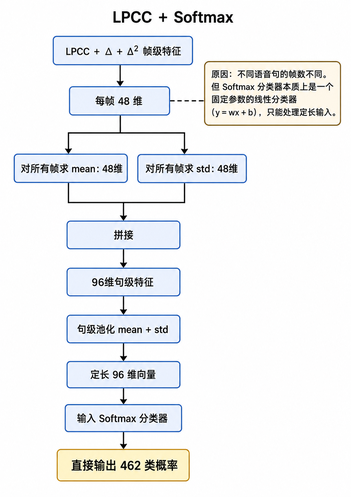

In [ ]:
# ============================================================
# 新增代码块：LPCC + Softmax 说话人识别实验
# ============================================================
# 设计思路：
# 1. 输入：复用 2.4.2 已构建好的 LPCC 句级帧序列
#    - X_train_lpcc_utt / y_train_lpcc_utt
#    - X_test_lpcc_utt  / y_test_lpcc_utt
# 2. 特征：把每句话的变长 LPCC 帧序列池化为定长向量
#    - mean pooling：描述整句话 LPCC 的平均声道结构
#    - std pooling ：描述整句话 LPCC 的帧间变化
# 3. 模型：多分类 LogisticRegression
#    - 对多分类任务等价于“线性层 + Softmax + 交叉熵”
#    - 适合作为 LPCC + Softmax 的轻量判别式基线
# 4. 评估：训练集 / 测试集 Accuracy、Top-3、Top-5、Macro-F1、Weighted-F1

import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    top_k_accuracy_score,
    confusion_matrix
)


# ----------------------------
# 二、实验配置
# ----------------------------
# 默认与 LPCC-GMM 主实验保持一致：静态 LPCC + Delta + Delta-Delta。
# 如需做消融，可改成：
#   'static'              -> 只用静态 LPCC
#   'static_delta'        -> LPCC + Delta
#   'static_delta_delta2' -> LPCC + Delta + Delta-Delta
LPCC_SOFTMAX_ORDER = globals().get('LPCC_BASE_ORDER', globals().get('LPCC_DATA_ORDER', globals().get('LPCC_ORDER', 16)))
LPCC_SOFTMAX_VARIANT = globals().get('LPCC_MAIN_VARIANT', 'static_delta_delta2')

# Logistic Regression 的 C 越小，L2 正则越强。
# 说话人类别多、每类样本少，适当正则化能减轻过拟合。
LPCC_SOFTMAX_C = 1.0
LPCC_SOFTMAX_MAX_ITER = 1000
LPCC_SOFTMAX_RANDOM_STATE = 42

print('=' * 72)
print('开始实验：LPCC + Softmax')
print('=' * 72)
print(f'LPCC阶数: {LPCC_SOFTMAX_ORDER}')
print(f'特征组合: {LPCC_SOFTMAX_VARIANT}')
print('句级池化方式: mean + std')
print(f'Softmax正则强度 C: {LPCC_SOFTMAX_C}')

# ----------------------------
# 三、变长 LPCC 序列 -> 定长句级向量
# ----------------------------
def lpcc_softmax_select_variant(sequences, order=LPCC_SOFTMAX_ORDER, variant=LPCC_SOFTMAX_VARIANT):
    """
    复用前面 LPCC-GMM 中的 select_lpcc_feature_variant。
    若该函数不存在，则默认直接使用输入序列。
    """
    if 'select_lpcc_feature_variant' in globals():
        return select_lpcc_feature_variant(sequences, order=order, variant=variant)
    return [np.asarray(seq, dtype=np.float32) for seq in sequences]

def lpcc_softmax_pool_utterances(sequences, order=LPCC_SOFTMAX_ORDER, variant=LPCC_SOFTMAX_VARIANT):
    """
    将每句话的 LPCC 帧序列池化成定长向量。

    输入：
        sequences: list[np.ndarray]，每个元素 shape = (帧数, 特征维度)

    输出：
        X_pool: np.ndarray，shape = (句子数, 2 * 特征维度)
                每句话向量 = [mean, std]
    """
    selected_sequences = lpcc_softmax_select_variant(sequences, order=order, variant=variant)

    pooled_features = []
    for frames in selected_sequences:
        frames = np.asarray(frames, dtype=np.float32)

        mean_feat = frames.mean(axis=0)
        std_feat = frames.std(axis=0)

        utt_feat = np.concatenate([mean_feat, std_feat], axis=0)
        pooled_features.append(utt_feat)

    return np.vstack(pooled_features).astype(np.float32)

lpcc_softmax_X_train = lpcc_softmax_pool_utterances(
    X_train_lpcc_utt,
    order=LPCC_SOFTMAX_ORDER,
    variant=LPCC_SOFTMAX_VARIANT
)

lpcc_softmax_X_test = lpcc_softmax_pool_utterances(
    X_test_lpcc_utt,
    order=LPCC_SOFTMAX_ORDER,
    variant=LPCC_SOFTMAX_VARIANT
)

lpcc_softmax_y_train = np.asarray(y_train_lpcc_utt, dtype=np.int64)
lpcc_softmax_y_test = np.asarray(y_test_lpcc_utt, dtype=np.int64)

print(f'训练集 Softmax 输入形状: {lpcc_softmax_X_train.shape}')
print(f'测试集 Softmax 输入形状: {lpcc_softmax_X_test.shape}')

# ----------------------------
# 四、标准化
# ----------------------------
# 只用训练集 fit scaler，避免测试集信息泄漏。
lpcc_softmax_scaler = StandardScaler()
lpcc_softmax_X_train_scaled = lpcc_softmax_scaler.fit_transform(lpcc_softmax_X_train)
lpcc_softmax_X_test_scaled = lpcc_softmax_scaler.transform(lpcc_softmax_X_test)

# ----------------------------
# 五、训练 Softmax 分类器
# ----------------------------
# LogisticRegression 在多分类时学习的是 Softmax 概率：
# P(y=k|x) = exp(w_k^T x + b_k) / sum_j exp(w_j^T x + b_j)
lpcc_softmax_clf = LogisticRegression(
    C=LPCC_SOFTMAX_C,
    solver='lbfgs',
    max_iter=LPCC_SOFTMAX_MAX_ITER,
    random_state=LPCC_SOFTMAX_RANDOM_STATE
)

lpcc_softmax_clf.fit(lpcc_softmax_X_train_scaled, lpcc_softmax_y_train)

print('LPCC + Softmax 训练完成')
print(f'Softmax权重矩阵形状: {lpcc_softmax_clf.coef_.shape}')

# ----------------------------
# 六、训练集 / 测试集评估
# ----------------------------
lpcc_softmax_y_pred_train = lpcc_softmax_clf.predict(lpcc_softmax_X_train_scaled)
lpcc_softmax_y_pred = lpcc_softmax_clf.predict(lpcc_softmax_X_test_scaled)

lpcc_softmax_y_proba_train = lpcc_softmax_clf.predict_proba(lpcc_softmax_X_train_scaled)
lpcc_softmax_y_proba = lpcc_softmax_clf.predict_proba(lpcc_softmax_X_test_scaled)

lpcc_softmax_train_acc = accuracy_score(lpcc_softmax_y_train, lpcc_softmax_y_pred_train)
lpcc_softmax_test_acc = accuracy_score(lpcc_softmax_y_test, lpcc_softmax_y_pred)

lpcc_softmax_top3_acc = top_k_accuracy_score(
    lpcc_softmax_y_test,
    lpcc_softmax_y_proba,
    k=3,
    labels=np.arange(NUM_CLASSES)
)

lpcc_softmax_top5_acc = top_k_accuracy_score(
    lpcc_softmax_y_test,
    lpcc_softmax_y_proba,
    k=5,
    labels=np.arange(NUM_CLASSES)
)

lpcc_softmax_macro_f1 = f1_score(
    lpcc_softmax_y_test,
    lpcc_softmax_y_pred,
    average='macro',
    zero_division=0
)

lpcc_softmax_weighted_f1 = f1_score(
    lpcc_softmax_y_test,
    lpcc_softmax_y_pred,
    average='weighted',
    zero_division=0
)

lpcc_softmax_result_df = pd.DataFrame([{
    '方法': 'LPCC + Softmax',
    'LPCC阶数': LPCC_SOFTMAX_ORDER,
    '特征组合': LPCC_SOFTMAX_VARIANT,
    '池化方式': 'mean + std',
    '输入维度': lpcc_softmax_X_train.shape[1],
    '训练集准确率(%)': lpcc_softmax_train_acc * 100,
    '测试集准确率(%)': lpcc_softmax_test_acc * 100,
    'Top-3准确率(%)': lpcc_softmax_top3_acc * 100,
    'Top-5准确率(%)': lpcc_softmax_top5_acc * 100,
    'Macro-F1(%)': lpcc_softmax_macro_f1 * 100,
    'Weighted-F1(%)': lpcc_softmax_weighted_f1 * 100,
}])

print('\nLPCC + Softmax 评估结果：')
display(lpcc_softmax_result_df)

# ----------------------------
# 七、与已有 LPCC-GMM 结果对比
# ----------------------------
lpcc_softmax_compare_rows = [{
    '方法': 'LPCC + Softmax',
    '模型类型': '判别式模型',
    '特征输入': '句级池化特征',
    '测试集准确率(%)': lpcc_softmax_test_acc * 100
}]

if 'lpcc_gmm_acc' in globals():
    lpcc_softmax_compare_rows.insert(0, {
        '方法': 'LPCC + GMM',
        '模型类型': '生成式模型',
        '特征输入': '帧级特征 + 句级似然判决',
        '测试集准确率(%)': float(lpcc_gmm_acc) * 100
    })

lpcc_softmax_compare_df = pd.DataFrame(lpcc_softmax_compare_rows)

#print('\nLPCC-GMM 与 LPCC-Softmax 对比：')
#display(lpcc_softmax_compare_df)

# ----------------------------
# 八、错误分析：找出最常见的混淆对
# ----------------------------
lpcc_softmax_cm = confusion_matrix(
    lpcc_softmax_y_test,
    lpcc_softmax_y_pred,
    labels=np.arange(NUM_CLASSES)
)

lpcc_softmax_cm_wo_diag = lpcc_softmax_cm.copy()
np.fill_diagonal(lpcc_softmax_cm_wo_diag, 0)

lpcc_softmax_error_rows = []
nonzero_pairs = np.argwhere(lpcc_softmax_cm_wo_diag > 0)

if len(nonzero_pairs) > 0:
    pair_counts = [
        (int(true_idx), int(pred_idx), int(lpcc_softmax_cm_wo_diag[true_idx, pred_idx]))
        for true_idx, pred_idx in nonzero_pairs
    ]
    pair_counts = sorted(pair_counts, key=lambda x: x[2], reverse=True)[:10]

    for true_idx, pred_idx, count in pair_counts:
        lpcc_softmax_error_rows.append({
            '真实说话人': le.classes_[true_idx],
            '预测说话人': le.classes_[pred_idx],
            '错分数量': count
        })

lpcc_softmax_error_df = pd.DataFrame(lpcc_softmax_error_rows)

if len(lpcc_softmax_error_df) > 0:
    print('\nLPCC + Softmax 最常见错分对 Top-10：')
    display(lpcc_softmax_error_df)
else:
    print('\nLPCC + Softmax 没有出现错分样本。')


开始实验：LPCC + Softmax
LPCC阶数: 16
特征组合: static_delta_delta2
句级池化方式: mean + std
Softmax正则强度 C: 1.0
训练集 Softmax 输入形状: (2772, 96)
测试集 Softmax 输入形状: (924, 96)
LPCC + Softmax 训练完成
Softmax权重矩阵形状: (462, 96)

LPCC + Softmax 评估结果：


,方法,LPCC阶数,特征组合,池化方式,输入维度,训练集准确率(%),测试集准确率(%),Top-3准确率(%),Top-5准确率(%),Macro-F1(%),Weighted-F1(%)
0,LPCC + Softmax,16,static_delta_delta2,mean + std,96,100.0,55.735931,72.727273,80.519481,53.123411,53.123411



LPCC + Softmax 最常见错分对 Top-10：


,真实说话人,预测说话人,错分数量
0,KLR0,JBG0,2
1,KSR0,DJH0,2
2,RVG0,GES0,2
3,ABC0,TKD0,1
4,ADC0,RJM0,1
5,ADD0,RAI0,1
6,ADD0,SFV0,1
7,AEO0,TCS0,1
8,AFM0,SRG0,1
9,AFM0,TRR0,1


本实验中的 LPCC + Softmax 模型采用“LPCC 特征提取 + 句级统计池化 + Softmax 分类器”的结构。首先对语音提取 16 阶 LPCC，并拼接一阶差分和二阶差分，形成 48 维帧级特征；随后对每条语音的所有帧分别计算均值和标准差，并拼接得到 96 维句级表示；最后将该句级向量输入多分类 Logistic Regression，相当于一个线性层加 Softmax 输出层，对 462 位说话人进行分类。实验结果显示，模型在训练集上达到 100% 准确率，但测试集准确率仅为 55.74%，说明该判别式模型在少样本、多类别场景下存在明显过拟合。Top-5 准确率达到 80.52%，表明 LPCC 特征仍包含有效说话人信息，但简单的线性 Softmax 分类边界泛化能力不足。相比之下，LPCC-GMM 直接利用帧级特征分布进行生成式建模，更适合当前每类训练语音数量较少的任务。

#### 4.2.4 LPCC + MFCC 特征融合实验
融合思路：

- LPCC：描述声道结构特征；
- MFCC：描述频谱感知特征；
- 每一帧将两者按列拼接，形成更丰富的特征向量；
- 再使用同样的 GMM 训练与句级判决流程。

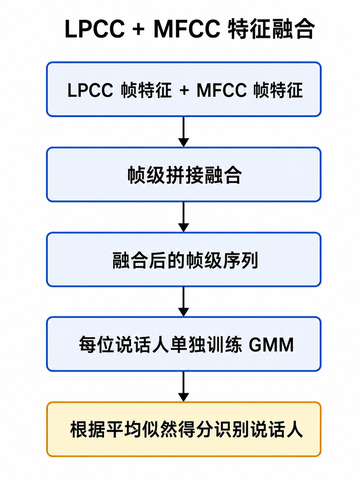

In [21]:

# ============================================================
# LPCC + MFCC 特征融合实验（新增版，不覆盖原有结果）
# ============================================================
# 使用说明：
# 1. 请先运行：
#    - 2.3 标签编码（得到 train_samples / test_samples / le）
#    - 3.1 MFCC 特征提取函数
#    - 3.2 LPCC 特征提取函数
#    - 4.2.1 LPCC-GMM 工具函数
# 2. 然后直接运行本单元即可。
#
# 本单元所有输出变量都以 fusion_ 开头，
# 因此不会覆盖你之前已经跑好的 LPCC-GMM 实验结果。

from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from tqdm import tqdm

# ----------------------------
# 一、可调参数（想提速可改这里）
# ----------------------------

# MFCC 维度。13 维是经典配置，速度快、效果稳定。
FUSION_MFCC_DIM = 13

# 是否保留 LPCC 的动态特征（Δ、Δ²）。
# True  表示使用完整 LPCC（静态+Δ+Δ²）
# False 表示只用静态 LPCC
FUSION_USE_FULL_LPCC = True

# GMM 分量数：
# 若你前面已经跑过最佳 LPCC-GMM，会自动继承最佳分量数；
# 否则默认 16。
#FUSION_GMM_COMPONENTS = globals().get('LPCC_GMM_COMPONENTS', 16)
FUSION_GMM_COMPONENTS = 8
# ----------------------------
# 二、单条语音提取“融合特征”
# ----------------------------

fusion_cache = {}

def get_lpcc_mfcc_fusion_frames(filepath):
    """
    对单条语音提取融合特征。

    返回：
        shape = (帧数, 特征维度)

    流程：
    1. 提取 LPCC 帧特征；
    2. 提取 MFCC 帧特征；
    3. 对齐帧数（取较短长度）；
    4. 按列拼接。
    """
    global fusion_cache

    if filepath in fusion_cache:
        return fusion_cache[filepath]

    # 读取 LPCC 特征
    lpcc = get_cached_lpcc_frames(filepath, lpcc_order=LPCC_DATA_ORDER)

    # 是否只保留静态 LPCC
    if not FUSION_USE_FULL_LPCC:
        lpcc = lpcc[:, :LPCC_DATA_ORDER]

    # 读取 MFCC 特征（每帧 13 维）
    mfcc = extract_mfcc_frames(filepath, n_mfcc=FUSION_MFCC_DIM)

    # ----------------------------
    # 对齐帧数
    # 因为两种特征提取方式的帧数可能略有不同
    # ----------------------------
    min_len = min(len(lpcc), len(mfcc))

    lpcc = lpcc[:min_len]
    mfcc = mfcc[:min_len]

    # 按列拼接：[LPCC | MFCC]
    fusion = np.hstack([lpcc, mfcc]).astype(np.float32)

    fusion_cache[filepath] = fusion
    return fusion

# ----------------------------
# 三、构建训练集 / 测试集
# ----------------------------

def build_fusion_dataset(samples, label_encoder, desc='构建融合特征'):
    """
    返回：
    1. X_frame : 所有训练帧拼接矩阵
    2. y_frame : 每帧标签
    3. utt_list : 每句话的变长帧序列
    4. y_utt   : 每句话标签
    """
    frame_blocks = []
    frame_labels = []

    utt_list = []
    utt_labels = []

    for item in tqdm(samples, desc=desc):
        feat = get_lpcc_mfcc_fusion_frames(item['filepath'])
        label = label_encoder.transform([item['speaker_id']])[0]

        # 帧级数据（给 GMM 训练）
        frame_blocks.append(feat)
        frame_labels.extend([label] * len(feat))

        # 句级数据（给整句预测）
        utt_list.append(feat)
        utt_labels.append(label)

    X_frame = np.vstack(frame_blocks).astype(np.float32)
    y_frame = np.asarray(frame_labels, dtype=np.int64)
    y_utt = np.asarray(utt_labels, dtype=np.int64)

    return X_frame, y_frame, utt_list, y_utt

print('=' * 72)
print('开始构建 LPCC + MFCC 融合数据集')
print('=' * 72)

fusion_X_train, fusion_y_train, fusion_train_utts, fusion_y_train_utt = build_fusion_dataset(
    train_samples, le, desc='训练集融合特征'
)

fusion_X_test_dummy, _, fusion_test_utts, fusion_y_test_utt = build_fusion_dataset(
    test_samples, le, desc='测试集融合特征'
)

# ----------------------------
# 四、仅用训练集统计量做标准化
# ----------------------------
fusion_mean = fusion_X_train.mean(axis=0, keepdims=True)
fusion_std = fusion_X_train.std(axis=0, keepdims=True) + 1e-8

fusion_X_train_norm = ((fusion_X_train - fusion_mean) / fusion_std).astype(np.float32)

fusion_train_utts_norm = [
    ((x - fusion_mean) / fusion_std).astype(np.float32)
    for x in fusion_train_utts
]

fusion_test_utts_norm = [
    ((x - fusion_mean) / fusion_std).astype(np.float32)
    for x in fusion_test_utts
]

# ----------------------------
# 五、训练 GMM（不会影响原模型）
# ----------------------------
print('=' * 72)
print(f'开始训练融合模型：GMM 分量数 = {FUSION_GMM_COMPONENTS}')
print('=' * 72)

fusion_gmm_models = train_lpcc_gmm_models(
    fusion_X_train_norm,
    fusion_y_train,
    NUM_CLASSES,
    n_components=FUSION_GMM_COMPONENTS,
    desc='训练融合 GMM'
)

# ----------------------------
# 六、训练集句级准确率（sanity check）
# ----------------------------
fusion_y_true_train, fusion_y_pred_train, fusion_y_conf_train, fusion_train_scores = predict_lpcc_gmm_utterances(
    fusion_train_utts_norm,
    fusion_y_train_utt,
    fusion_gmm_models,
    NUM_CLASSES,
    desc='融合模型训练集预测'
)

fusion_train_acc = accuracy_score(fusion_y_true_train, fusion_y_pred_train)

# ----------------------------
# 七、测试集句级准确率
# ----------------------------
fusion_y_true, fusion_y_pred, fusion_y_conf, fusion_test_scores = predict_lpcc_gmm_utterances(
    fusion_test_utts_norm,
    fusion_y_test_utt,
    fusion_gmm_models,
    NUM_CLASSES,
    desc='融合模型测试集预测'
)

fusion_test_acc = accuracy_score(fusion_y_true, fusion_y_pred)

# ----------------------------
# 八、结果输出（原结果仍然保留）
# ----------------------------
print('\n' + '=' * 72)
print('LPCC + MFCC 融合实验完成')
print('=' * 72)
print(f'训练集句级准确率：{fusion_train_acc:.4f} ({fusion_train_acc*100:.2f}%)')
print(f'测试集句级准确率：{fusion_test_acc:.4f} ({fusion_test_acc*100:.2f}%)')

# 与原 LPCC-GMM 做对比（如果之前已运行）
compare_rows = []

if 'lpcc_gmm_acc' in globals():
    compare_rows.append({
        '方法': '原 LPCC-GMM',
        '测试集句级准确率(%)': lpcc_gmm_acc * 100
    })

compare_rows.append({
    '方法': 'LPCC + MFCC 融合 GMM',
    '测试集句级准确率(%)': fusion_test_acc * 100
})

fusion_compare_df = pd.DataFrame(compare_rows)

print('\n结果对比：')
display(fusion_compare_df)


开始构建 LPCC + MFCC 融合数据集


测试集融合特征: 100%|██████████| 924/924 [00:05<00:00, 181.69it/s]


开始训练融合模型：GMM 分量数 = 8


融合模型测试集预测: 100%|██████████| 924/924 [01:13<00:00, 12.63it/s]


LPCC + MFCC 融合实验完成
训练集句级准确率：1.0000 (100.00%)
测试集句级准确率：0.6710 (67.10%)

结果对比：


,方法,测试集句级准确率(%)
0,原 LPCC-GMM,96.753247
1,LPCC + MFCC 融合 GMM,67.099567


##### 引入PCA降维：

In [ ]:
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
from tqdm import tqdm

print('=' * 72)
print('开始进行：LPCC+MFCC 融合特征 + PCA降维 + GMM 新实验')
print('=' * 72)

# ===============================================================
# 一、检查上一代码块变量是否存在
# ===============================================================

required_vars = [
    'fusion_X_train_norm',
    'fusion_train_utts_norm',
    'fusion_test_utts_norm',
    'fusion_y_train',
    'fusion_y_train_utt',
    'fusion_y_test_utt'
]

for var in required_vars:
    if var not in globals():
        raise ValueError(f'缺少变量 {var}，请先运行上一代码块（融合实验）')

# ===============================================================
# 二、PCA参数（你可自行修改）
# ===============================================================

FUSION_PCA_DIM = 15          # 降到15维（推荐）
FUSION_PCA_GMM = 8          # GMM分量数（建议8）

# ===============================================================
# 三、训练集做PCA拟合
# 只用训练集学习主成分，防止数据泄露
# ===============================================================

print(f'开始PCA降维：{fusion_X_train_norm.shape[1]}维 -> {FUSION_PCA_DIM}维')

fusion_pca_model = PCA(
    n_components=FUSION_PCA_DIM,
    random_state=42
)

fusion_X_train_pca = fusion_pca_model.fit_transform(
    fusion_X_train_norm
).astype(np.float32)

# ===============================================================
# 四、将每句话变长特征也映射到PCA空间
# ===============================================================

fusion_train_utts_pca = [
    fusion_pca_model.transform(x).astype(np.float32)
    for x in tqdm(fusion_train_utts_norm, desc='训练集句子PCA变换')
]

fusion_test_utts_pca = [
    fusion_pca_model.transform(x).astype(np.float32)
    for x in tqdm(fusion_test_utts_norm, desc='测试集句子PCA变换')
]

print('PCA完成')
print('累计信息保留率：{:.2f}%'.format(
    fusion_pca_model.explained_variance_ratio_.sum() * 100
))

# ===============================================================
# 五、重新训练 GMM（复用你原来的训练函数）
# ===============================================================

print('=' * 72)
print(f'开始训练 PCA-GMM 模型：GMM 分量数 = {FUSION_PCA_GMM}')
print('=' * 72)

fusion_pca_gmm_models = train_lpcc_gmm_models(
    fusion_X_train_pca,
    fusion_y_train,
    NUM_CLASSES,
    n_components=FUSION_PCA_GMM,
    desc='训练 PCA-GMM'
)

# ===============================================================
# 六、训练集句级预测
# ===============================================================

fusion_pca_y_true_train, \
fusion_pca_y_pred_train, \
fusion_pca_y_conf_train, \
fusion_pca_train_scores = predict_lpcc_gmm_utterances(
    fusion_train_utts_pca,
    fusion_y_train_utt,
    fusion_pca_gmm_models,
    NUM_CLASSES,
    desc='PCA模型训练集预测'
)

fusion_pca_train_acc = accuracy_score(
    fusion_pca_y_true_train,
    fusion_pca_y_pred_train
)

# ===============================================================
# 七、测试集句级预测
# ===============================================================

fusion_pca_y_true, \
fusion_pca_y_pred, \
fusion_pca_y_conf, \
fusion_pca_test_scores = predict_lpcc_gmm_utterances(
    fusion_test_utts_pca,
    fusion_y_test_utt,
    fusion_pca_gmm_models,
    NUM_CLASSES,
    desc='PCA模型测试集预测'
)

fusion_pca_test_acc = accuracy_score(
    fusion_pca_y_true,
    fusion_pca_y_pred
)

# ===============================================================
# 八、输出结果（不会覆盖旧结果）
# ===============================================================

print('\n' + '=' * 72)
print('融合 + PCA + GMM 实验完成')
print('=' * 72)

print(f'训练集句级准确率：{fusion_pca_train_acc:.4f} ({fusion_pca_train_acc*100:.2f}%)')
print(f'测试集句级准确率：{fusion_pca_test_acc:.4f} ({fusion_pca_test_acc*100:.2f}%)')

# ===============================================================
# 九、结果对比（保留原结果并新增）
# ===============================================================

compare_rows = []

if 'lpcc_gmm_acc' in globals():
    compare_rows.append({
        '方法': '原 LPCC-GMM',
        '测试集句级准确率(%)': lpcc_gmm_acc * 100
    })

if 'fusion_test_acc' in globals():
    compare_rows.append({
        '方法': 'LPCC + MFCC 融合 GMM',
        '测试集句级准确率(%)': fusion_test_acc * 100
    })

compare_rows.append({
    '方法': '融合 + PCA + GMM',
    '测试集句级准确率(%)': fusion_pca_test_acc * 100
})

fusion_pca_compare_df = pd.DataFrame(compare_rows)

print('\n结果对比：')
display(fusion_pca_compare_df)

开始进行：LPCC+MFCC 融合特征 + PCA降维 + GMM 新实验
开始PCA降维：61维 -> 15维


测试集句子PCA变换: 100%|██████████| 924/924 [00:00<00:00, 6369.70it/s]


PCA完成
累计信息保留率：45.30%
开始训练 PCA-GMM 模型：GMM 分量数 = 8


PCA模型测试集预测: 100%|██████████| 924/924 [01:05<00:00, 14.16it/s]


融合 + PCA + GMM 实验完成
训练集句级准确率：0.9982 (99.82%)
测试集句级准确率：0.4264 (42.64%)

结果对比：


,方法,测试集句级准确率(%)
0,原 LPCC-GMM,96.753247
1,LPCC + MFCC 融合 GMM,67.099567
2,融合 + PCA + GMM,42.640693


### 4.3 Fbank + GMM / SVM

使用 Fbank 特征训练多组模型，与 MFCC 实验形成三组对比：
- **对比1**：同模型(GMM)同特征类型(统计特征)，Fbank vs MFCC
- **对比2**：同模型(GMM 帧特征 n=16)，Fbank vs MFCC
- **对比3**：同特征(Fbank 统计特征)，SVM vs GMM

#### 4.3.1 GMM + Fbank 帧特征 (n=1, 2, 4, 8, 16)

与 MFCC+GMM 帧特征同结构：每位说话人独立训练一个 GMM。每人约 570 帧，可支持较多高斯分量。使用 `init_params='random'` 避免 KMeans 初始化在 Windows 上的兼容问题，n=16 时加大 `reg_covar=1e-2` 防止协方差退化。

最终结果：n=1(29.87%) → n=2(41.77%) → n=4(62.66%) → n=8(74.78%) → **n=16(80.41%)**，高斯分量越多准确率越高。

In [ ]:
from tqdm import tqdm

# GMM + Fbank 帧特征，遍历不同高斯分量数
gmm_fbank_frames = {}  # 保存所有配置: gmm_fbank_frames[n] = {spk_idx: gmm}
for n in [1, 2, 4, 8, 16]:
    reg = 1e-2 if n >= 16 else 1e-3
    models = {}
    for spk_idx in tqdm(range(NUM_CLASSES), desc=f'GMM Fbank frames n={n}'):
        mask = (y_train_fbank_frames == spk_idx)
        gmm = GaussianMixture(n_components=n, covariance_type='diag',
                              max_iter=200, random_state=42,
                              init_params='random', reg_covar=reg)
        gmm.fit(X_train_fbank_frames[mask])
        models[spk_idx] = gmm
    gmm_fbank_frames[n] = models
print(f'GMM Fbank 帧特征训练完成: n={list(gmm_fbank_frames.keys())}')

#### 4.3.2 GMM + Fbank 统计特征 (n=1, 2, 4)

与 MFCC+GMM 统计特征对齐。每人仅 6 条样本，高斯分量数不能超过样本数。n 越大参数量越多，容易过拟合——n=4 时参数量 4×161=644，超过样本数据量 6×80=480。

最终结果：**n=1(22.94%)**，n=2(15.69%)，n=4(5.63%)，n 越大反而越差，严重过拟合。

In [ ]:
# GMM + Fbank 统计特征，与队友 MFCC n=1,2,4 对齐
gmm_fbank_mean = {}  # gmm_fbank_mean[n] = {spk_idx: gmm}
for n, reg in [(1, 1e-5), (2, 1e-4), (4, 1e-3)]:
    models = {}
    for spk_idx in range(NUM_CLASSES):
        mask = (y_train_fbank == spk_idx)
        gmm = GaussianMixture(n_components=n, covariance_type='diag',
                              max_iter=200, random_state=42, reg_covar=reg)
        try:
            gmm.fit(X_train_fbank[mask])
        except ValueError:
            # n>1 时 6 条样本可能不够，fallback 到 n=1
            gmm = GaussianMixture(n_components=1, covariance_type='diag',
                                  max_iter=200, random_state=42, reg_covar=reg*10)
            gmm.fit(X_train_fbank[mask])
        models[spk_idx] = gmm
    gmm_fbank_mean[n] = models
print(f'GMM Fbank 统计特征训练完成: n={list(gmm_fbank_mean.keys())}')

#### 4.3.3 SVM (RBF) + Fbank 统计特征

用 SVM 作为判别式模型代表，与 GMM（生成式模型）对比。Fbank 维度间相关性高，理论上更适合 SVM 这种直接学习类间决策边界的判别式模型。使用 StandardScaler 标准化特征，RBF 核，OvR 策略处理 462 分类。

最终结果：**SVM 40.48%**，优于同特征下 GMM(22.94%)，验证了 Fbank 更适合判别式模型的假设。

In [ ]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

scaler_fbank = StandardScaler()
X_train_fbank_scaled = scaler_fbank.fit_transform(X_train_fbank)
svm_fbank = SVC(kernel='rbf', C=10, gamma='scale', decision_function_shape='ovr')
svm_fbank.fit(X_train_fbank_scaled, y_train_fbank)
print(f'SVM 训练完成, 训练集准确率: {svm_fbank.score(X_train_fbank_scaled, y_train_fbank):.2%}')

## 5. 评价指标(准确率Accuracy)

### 5.1 MFCC-GMM

#### 5.1.1 MFCC统计特征

高斯分量为4

In [ ]:
## 请编写代码或使用库函数accuracy_score计算测试集上的准确率Accuracy
# GMM 预测
def gmm_predict(X, gmm_models, num_classes):
    # 构建得分矩阵 shape: (N, num_classes)
    # scores_per_sample[i, j] = 第i条测试样本在第j位说话人GMM下的log-likelihood
    scores_per_sample = np.zeros((len(X), num_classes))
    for spk_idx in range(num_classes):
        scores_per_sample[:, spk_idx] = gmm_models[spk_idx].score_samples(X)
    # 每条样本取得分最高的说话人作为预测结果
    return scores_per_sample.argmax(axis=1)

y_pred_gmm = gmm_predict(X_test_flat, gmm_models_mean4, NUM_CLASSES)
acc_gmm = accuracy_score(y_test, y_pred_gmm)
print(f"GMM 测试集准确率: {acc_gmm:.4f} ({acc_gmm*100:.2f}%)")

GMM 测试集准确率: 0.1223 (12.23%)


准确率比较低，原因：参数不足  
每个分量需要：  
  μ：80个均值  
  σ²：80个方差（diag）  
  w：1个权重  

4个分量总参数量 = 4 × (80 + 80 + 1) = 644个参数  
训练样本数 = 6条 × 80维 = 480个数值  

样本数<参数 → 严重过拟合/欠拟合  

高斯分量为2

In [ ]:
## 请编写代码或使用库函数accuracy_score计算测试集上的准确率Accuracy
# GMM 预测
def gmm_predict(X, gmm_models, num_classes):
    # 构建得分矩阵 shape: (N, num_classes)
    # scores_per_sample[i, j] = 第i条测试样本在第j位说话人GMM下的log-likelihood
    scores_per_sample = np.zeros((len(X), num_classes))
    for spk_idx in range(num_classes):
        scores_per_sample[:, spk_idx] = gmm_models[spk_idx].score_samples(X)
    # 每条样本取得分最高的说话人作为预测结果
    return scores_per_sample.argmax(axis=1)

y_pred_gmm = gmm_predict(X_test_flat, gmm_models_mean2, NUM_CLASSES)
acc_gmm = accuracy_score(y_test, y_pred_gmm)
print(f"GMM 测试集准确率: {acc_gmm:.4f} ({acc_gmm*100:.2f}%)")

GMM 测试集准确率: 0.3626 (36.26%)


高斯分量为1

In [ ]:
## 请编写代码或使用库函数accuracy_score计算测试集上的准确率Accuracy
# GMM 预测
def gmm_predict(X, gmm_models, num_classes):
    # 构建得分矩阵 shape: (N, num_classes)
    # scores_per_sample[i, j] = 第i条测试样本在第j位说话人GMM下的log-likelihood
    scores_per_sample = np.zeros((len(X), num_classes))
    for spk_idx in range(num_classes):
        scores_per_sample[:, spk_idx] = gmm_models[spk_idx].score_samples(X)
    # 每条样本取得分最高的说话人作为预测结果
    return scores_per_sample.argmax(axis=1)

y_pred_gmm = gmm_predict(X_test_flat, gmm_models_mean1, NUM_CLASSES)
acc_gmm = accuracy_score(y_test, y_pred_gmm)
print(f"GMM 测试集准确率: {acc_gmm:.4f} ({acc_gmm*100:.2f}%)")

GMM 测试集准确率: 0.6407 (64.07%)


#### 5.1.2 MFCC帧特征

In [ ]:
def gmm_predict_frames(samples, gmm_models, label_encoder, num_classes):
    """
    对每句话：先算每帧在各GMM下的得分，累加后取argmax
    """
    y_pred = []
    for item in samples:
        frames = extract_mfcc_frames(item["filepath"])  # (帧数, 40)
        
        # 每个GMM对这句话所有帧的得分求和
        # score() 返回的是平均log-likelihood，乘帧数得到总分
        scores = np.array([
            gmm_models[i].score(frames) for i in range(num_classes)
        ])
        y_pred.append(scores.argmax())
    return np.array(y_pred)

y_pred_gmm = gmm_predict_frames(test_samples, gmm_models_frame, le, NUM_CLASSES)
y_test_sent = np.array([le.transform([s["speaker_id"]])[0] for s in test_samples])
acc = accuracy_score(y_test_sent, y_pred_gmm)
print(f"GMM（帧级别）测试准确率: {acc:.4f} ({acc*100:.2f}%)")

GMM（帧级别）测试准确率: 0.8972 (89.72%)


### 5.2 LPCC-GMM 句级评估与实验对比


In [ ]:
# ============================================================
# LPCC-GMM 句级评估与对比
# ============================================================
# 本单元不重新训练模型，只读取 4.2.2 已经选出的最佳 LPCC-GMM 结果。
# 主要输出：
# 1. 最佳 LPCC-GMM 的句级准确率；
# 2. 不同 GMM 分量数对比表；
# 3. Delta 特征消融表；
# 4. 与第一个人的 MFCC-GMM 结果做简单对比。

required_vars = [
    'lpcc_gmm_acc',
    'lpcc_gmm_train_acc',
    'lpcc_gmm_best_config',
    'lpcc_component_results_df',
    'y_conf_lpcc_gmm',
    'y_true_lpcc_gmm',
    'y_pred_lpcc_gmm'
]

missing_vars = [name for name in required_vars if name not in globals()]

if missing_vars:
    print('请先运行 4.2.1 和 4.2.2 中与笑儿相关的 LPCC-GMM 单元。')
    print('当前缺少变量：' + ', '.join(missing_vars))
else:
    print('LPCC-GMM 最佳配置：')
    for k, v in lpcc_gmm_best_config.items():
        if '准确率' in k:
            print(f'{k}: {v:.4f} ({v * 100:.2f}%)')
        else:
            print(f'{k}: {v}')

    print('\nLPCC-GMM 句级测试结果：')
    print(f'训练集句级准确率 sanity check: {lpcc_gmm_train_acc:.4f} ({lpcc_gmm_train_acc * 100:.2f}%)')
    print(f'测试集句级准确率: {lpcc_gmm_acc:.4f} ({lpcc_gmm_acc * 100:.2f}%)')
    print(f'平均近似置信度: {np.mean(y_conf_lpcc_gmm):.4f}')

    if lpcc_gmm_acc >= 0.80:
        print('已达到 80%+ 的目标。')
    else:
        print('尚未达到 80%。建议优先观察分量数对比表，选择 8/12/16/24 中更稳的配置；必要时再考虑与 MFCC-GMM 分数融合。')

    print('\n不同 GMM 分量数对比表：')
    display(lpcc_component_results_df)

    if 'lpcc_delta_ablation_results_df' in globals() and len(lpcc_delta_ablation_results_df) > 0:
        print('\nLPCC / LPCC+Δ / LPCC+Δ+Δ² 消融表：')
        display(lpcc_delta_ablation_results_df)

    if 'lpcc_order_results_df' in globals() and len(lpcc_order_results_df) > 0:
        print('\nLPCC 阶数对比表：')
        display(lpcc_order_results_df)

    # ----------------------------
    # 与 MFCC-GMM 做对比
    # ----------------------------
    # 说明：
    # - 第一个人的 MFCC 帧级 GMM 在 5.1.2 中把准确率保存为变量 acc；
    # - 如果你已经运行过 5.1.2，这里会自动读取 acc；
    # - 如果没有运行过 5.1.2，这里只显示 LPCC-GMM 自己的结果。
    comparison_rows = [{
        '方法': f"LPCC-GMM（{lpcc_gmm_best_config['特征组合']}，{lpcc_gmm_best_config['GMM分量数']}分量）",
        '特征级别': '帧级特征 + 句级判决',
        '句级准确率': lpcc_gmm_acc,
        '句级准确率(%)': lpcc_gmm_acc * 100,
    }]

    if 'acc' in globals():
        comparison_rows.insert(0, {
            '方法': 'MFCC-GMM（帧级特征）',
            '特征级别': '帧级特征 + 句级判决',
            '句级准确率': float(acc),
            '句级准确率(%)': float(acc) * 100,
        })
    else:
        print('\n提示：如果想自动生成 MFCC-GMM vs LPCC-GMM 对比表，请先运行 5.1.2 的 MFCC帧级GMM评估单元。')

    lpcc_mfcc_comparison_df = pd.DataFrame(comparison_rows)
    print('\nMFCC-GMM 与 LPCC-GMM 对比：')
    display(lpcc_mfcc_comparison_df)


LPCC-GMM 最佳配置：
LPCC阶数: 16
特征组合: LPCC + Δ + Δ²
特征维度: 48
GMM分量数: 16
训练集句级准确率: 1.0000 (100.00%)
测试集句级准确率: 0.9675 (96.75%)

LPCC-GMM 句级测试结果：
训练集句级准确率 sanity check: 1.0000 (100.00%)
测试集句级准确率: 0.9675 (96.75%)
平均近似置信度: 0.2947
已达到 80%+ 的目标。

不同 GMM 分量数对比表：


,实验,LPCC阶数,特征组合,特征维度,GMM分量数,训练集句级准确率,测试集句级准确率,测试集句级准确率(%),训练集句级准确率(%)
0,GMM分量数对比,16,LPCC + Δ + Δ²,48,4,0.996032,0.877706,87.770563,99.603175
1,GMM分量数对比,16,LPCC + Δ + Δ²,48,8,1.000000,0.941558,94.155844,100.000000
2,GMM分量数对比,16,LPCC + Δ + Δ²,48,12,1.000000,0.953463,95.346320,100.000000
3,GMM分量数对比,16,LPCC + Δ + Δ²,48,16,1.000000,0.967532,96.753247,100.000000
4,GMM分量数对比,16,LPCC + Δ + Δ²,48,24,1.000000,0.966450,96.645022,100.000000



LPCC / LPCC+Δ / LPCC+Δ+Δ² 消融表：


,实验,LPCC阶数,特征组合,特征维度,GMM分量数,训练集句级准确率,测试集句级准确率,测试集句级准确率(%),训练集句级准确率(%)
0,Delta特征消融,16,LPCC + Δ + Δ²,48,16,1.0,0.967532,96.753247,100.0
1,Delta特征消融,16,LPCC,16,16,1.0,0.965368,96.536797,100.0
2,Delta特征消融,16,LPCC + Δ,32,16,1.0,0.972944,97.294372,100.0



LPCC 阶数对比表：


,实验,LPCC阶数,特征组合,特征维度,GMM分量数,训练集句级准确率,测试集句级准确率,测试集句级准确率(%),训练集句级准确率(%)
0,LPCC阶数对比,12,LPCC + Δ + Δ²,36,16,1.0,0.949134,94.913420,100.0
1,LPCC阶数对比,16,LPCC + Δ + Δ²,48,16,1.0,0.967532,96.753247,100.0
2,LPCC阶数对比,20,LPCC + Δ + Δ²,60,16,1.0,0.975108,97.510823,100.0



提示：如果想自动生成 MFCC-GMM vs LPCC-GMM 对比表，请先运行 5.1.2 的 MFCC帧级GMM评估单元。

MFCC-GMM 与 LPCC-GMM 对比：


,方法,特征级别,句级准确率,句级准确率(%)
0,LPCC-GMM（LPCC + Δ + Δ²，16分量）,帧级特征 + 句级判决,0.967532,96.753247


### 5.3 Fbank特征 模型评估

分别评估三类模型的测试集准确率：
- GMM + Fbank 帧特征：对每句话累加所有帧在各说话人 GMM 下的对数似然，取 argmax
- GMM + Fbank 统计特征：直接用 80 维向量在各 GMM 下打分
- SVM + Fbank 统计特征：用训练好的 SVM 直接预测

In [ ]:
# 5.3 评估 Fbank 模型
def gmm_predict_fbank_frames(samples, gmm_models_n, num_classes):
    """对每句话：每帧在各 GMM 下打分，累加取 argmax"""
    y_pred = []
    for item in samples:
        frames = extract_fbank_frames(item['filepath'])
        scores = np.array([gmm_models_n[i].score(frames) for i in range(num_classes)])
        y_pred.append(scores.argmax())
    return np.array(y_pred)

y_test_sent = np.array([le.transform([s['speaker_id']])[0] for s in test_samples])

# GMM + Fbank 帧特征，遍历所有 n
print('GMM + Fbank 帧特征:')
for n in [1, 2, 4, 8, 16]:
    y_pred = gmm_predict_fbank_frames(test_samples, gmm_fbank_frames[n], NUM_CLASSES)
    acc = accuracy_score(y_test_sent, y_pred)
    print(f'  n={n:2d}: {acc:.2%}')

# GMM + Fbank 统计特征，遍历所有 n
print('\nGMM + Fbank 统计特征:')
for n in [1, 2, 4]:
    y_pred = gmm_predict(X_test_fbank, gmm_fbank_mean[n], NUM_CLASSES)
    acc = accuracy_score(y_test_fbank, y_pred)
    print(f'  n={n}: {acc:.2%}')

# SVM (RBF) + Fbank 统计特征
X_test_scaled = scaler_fbank.transform(X_test_fbank)
y_pred_svm = svm_fbank.predict(X_test_scaled)
acc_svm = accuracy_score(y_test_fbank, y_pred_svm)
print(f'\nSVM (RBF) + Fbank 统计特征: {acc_svm:.2%}')

Fbank 帧特征 + GMM 达到 **80.41%**，远高于统计特征的 22.94%。帧级别每人约 570 帧训练数据，足以支撑 n=16 的 GMM 充分拟合特征分布；而统计特征仅 6 条样本（每人 480 个数值），信息量严重不足。

SVM(40.48%) 优于 GMM(22.94%)，说明 Fbank 特征更适合判别式模型——SVM 直接学习类间决策边界，对 Fbank 维度间的高相关性有更强的处理能力。

##  6. 分析和可视化

### 6.1 GMM

#### 6.1.1 可视化第一个说话人的帧特征高斯分布模型

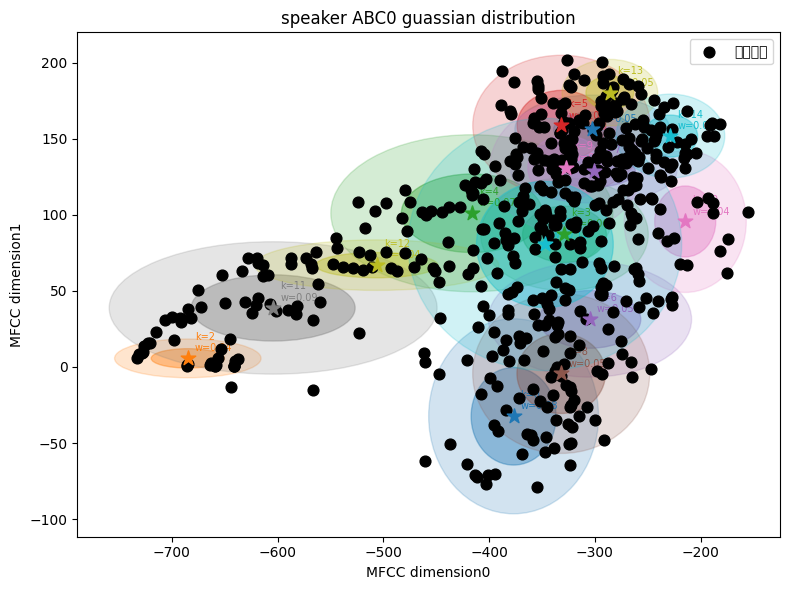

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse

def plot_gmm_components(gmm, X_spk, spk_name, dims=(0, 1)):
    """
    画出 GMM 的高斯分量分布（取第dims[0]和dims[1]维做2D投影）
    gmm:    训练好的 GaussianMixture
    X_spk:  该说话人的训练样本
    """
    d0, d1 = dims
    fig, ax = plt.subplots(figsize=(8, 6))

    # 画训练样本散点
    ax.scatter(X_spk[:, d0], X_spk[:, d1],
               c='black', s=60, zorder=5, label='训练样本')

    # 画每个高斯分量
    colors = plt.cm.tab10(np.linspace(0, 1, len(gmm.means_)))
    for k, (mean, cov, w) in enumerate(zip(gmm.means_, gmm.covariances_, gmm.weights_)):
        # 取对应维度的均值和标准差
        mx, my = mean[d0], mean[d1]
        sx, sy = np.sqrt(cov[d0]), np.sqrt(cov[d1])

        # 画分量中心
        ax.scatter(mx, my, c=[colors[k]], s=120, marker='*', zorder=6)

        # 画1σ和2σ椭圆
        for n_std, alpha in [(1, 0.4), (2, 0.2)]:
            ellipse = Ellipse(
                xy=(mx, my),
                width=2 * n_std * sx,
                height=2 * n_std * sy,
                angle=0,
                color=colors[k], alpha=alpha
            )
            ax.add_patch(ellipse)

        ax.annotate(f'k={k}\nw={w:.2f}', xy=(mx, my),
                    fontsize=7, color=colors[k],
                    xytext=(5, 5), textcoords='offset points')

    ax.set_xlabel(f'MFCC dimension{d0}')
    ax.set_ylabel(f'MFCC dimension{d1}')
    ax.set_title(f'speaker {spk_name} guassian distribution')
    ax.legend()
    plt.tight_layout()
    plt.show()

# 取第一个说话人
spk0_name = le.classes_[0]
mask0 = (y_train_frames == 0)
X_spk0 = X_train_frames[mask0]   # 该说话人所有帧，shape: (总帧数, 40)

plot_gmm_components(gmm_models_frame[0], X_spk0, spk0_name, dims=(0, 1))

#### 6.1.2 四个模型的混淆矩阵（取前20位说话人）

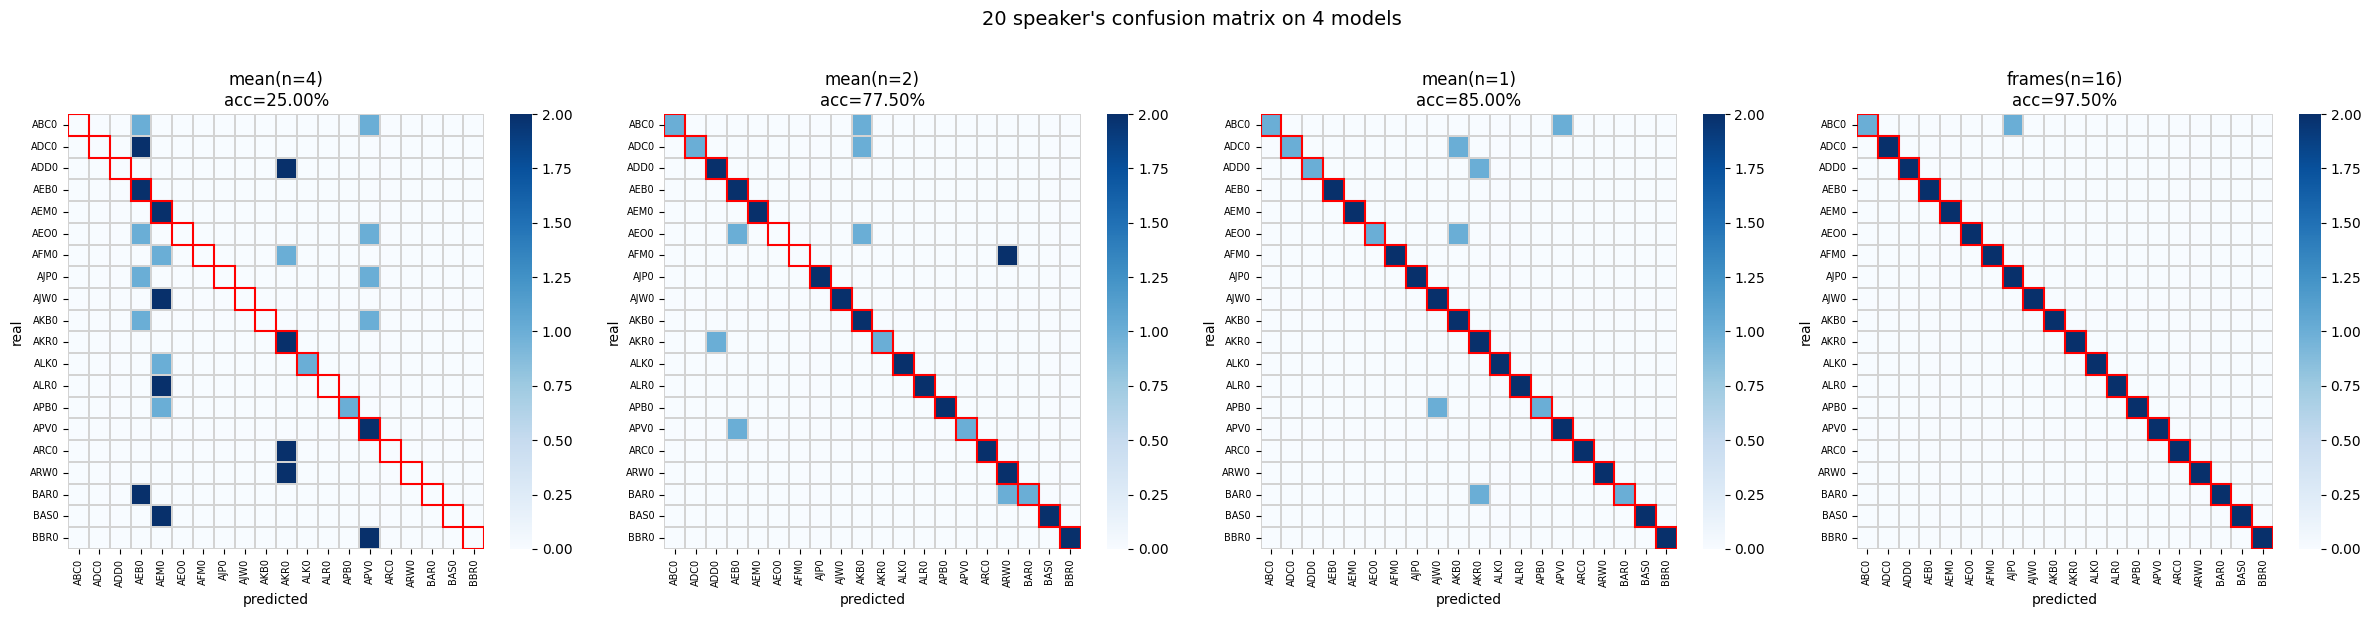

In [41]:
def plot_confusion_matrix_compare(test_samples, gmm_models_dict, label_encoder, n_speakers=20):
    spk_names   = label_encoder.classes_[:n_speakers]
    sub_samples = [s for s in test_samples if s["speaker_id"] in spk_names]
    model_names = list(gmm_models_dict.keys())
    n_models    = len(model_names)

    y_true = np.array([
        label_encoder.transform([s["speaker_id"]])[0] for s in sub_samples
    ])

    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 6))

    for ax, model_name in zip(axes, model_names):
        gmm_models = gmm_models_dict[model_name]

        y_pred = []
        for item in sub_samples:
            if model_name.startswith('frames'):
                feat = extract_mfcc_frames(item["filepath"])
            else:
                feat = extract_mfcc_mean(item["filepath"]).reshape(1, -1)
            scores = np.array([gmm_models[i].score(feat) for i in range(n_speakers)])
            y_pred.append(scores.argmax())

        y_pred = np.array(y_pred)
        acc    = (y_pred == y_true).mean()
        cm     = confusion_matrix(y_true, y_pred, labels=list(range(n_speakers)))

        sns.heatmap(
            cm, ax=ax,
            cmap='Blues',           # 颜色越深=数值越大
            xticklabels=spk_names,
            yticklabels=spk_names,
            annot=False,            # 不写数字，只用颜色
            linewidths=0.3,         # 格子间细线，方便区分
            linecolor='lightgray',
            vmin=0, vmax=2,         # 固定色阶范围（每人最多2条测试句）
            cbar=True
        )

        # 手动高亮对角线边框
        for i in range(n_speakers):
            ax.add_patch(plt.Rectangle(
                (i, i), 1, 1,
                fill=False, edgecolor='red', linewidth=1.5
            ))

        ax.set_title(f'{model_name}\nacc={acc:.2%}', fontsize=12)
        ax.set_xlabel('predicted', fontsize=10)
        ax.set_ylabel('real', fontsize=10)
        ax.tick_params(axis='x', rotation=90, labelsize=7)
        ax.tick_params(axis='y', rotation=0,  labelsize=7)

    plt.suptitle(f'{n_speakers} speaker\'s confusion matrix on 4 models ', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix_compare(
    test_samples,
    gmm_models_dict={
        'mean(n=4)':    gmm_models_mean4,
        'mean(n=2)':    gmm_models_mean2,
        'mean(n=1)':    gmm_models_mean1,
        'frames(n=16)': gmm_models_frame,
    },
    label_encoder=le,
    n_speakers=20
)

混淆矩阵的着色块[i][j]表示第i个说话人说的话被识别为第j个说话人说的，因此我们希望着色块尽可能在对角线上；可以看到从使用统计特征的模型到使用帧特征的模型，以及在使用统计特征的模型内部随着高斯分量的减少，模型的效果在越来越好

### 6.2 LPCC-GMM 结果可视化


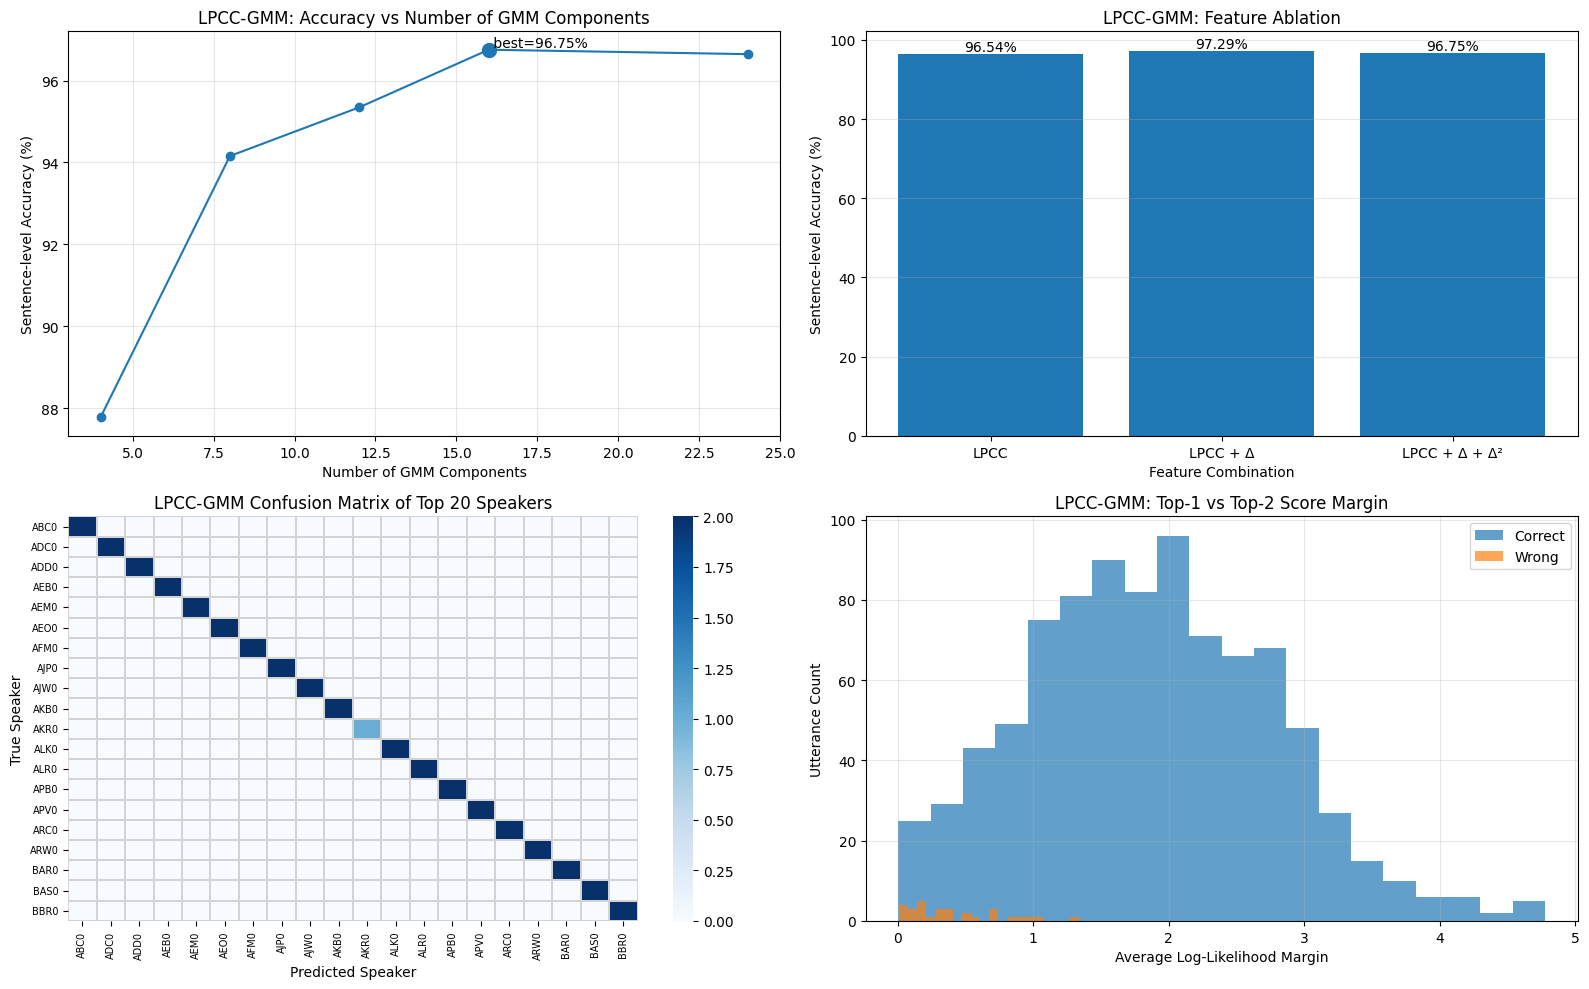

In [ ]:
# ============================================================
# LPCC-GMM 结果可视化
# ============================================================
# 本单元会画四类图：
# 1. 不同 GMM 分量数 vs 测试准确率；
# 2. LPCC 动态特征消融结果；
# 3. 前 20 位说话人的句级混淆矩阵；
# 4. Top-1 与 Top-2 GMM 得分差分布。
#
# 这些图可以直接用于报告中的“实验结果与分析”部分。

def plot_lpcc_component_comparison(results_df, ax=None, show=True):
    """画不同 GMM 分量数下的测试集句级准确率。"""
    if results_df is None or len(results_df) == 0:
        print('没有 GMM 分量数对比结果，跳过该图。')
        return

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    plot_df = results_df.sort_values('GMM分量数')

    ax.plot(
        plot_df['GMM分量数'],
        plot_df['测试集句级准确率(%)'],
        marker='o'
    )
    ax.set_title('LPCC-GMM: Accuracy vs Number of GMM Components')
    ax.set_xlabel('Number of GMM Components')
    ax.set_ylabel('Sentence-level Accuracy (%)')
    ax.grid(alpha=0.3)

    best_idx = plot_df['测试集句级准确率(%)'].idxmax()
    best_row = plot_df.loc[best_idx]
    ax.scatter([best_row['GMM分量数']], [best_row['测试集句级准确率(%)']], s=100)
    ax.text(
        best_row['GMM分量数'],
        best_row['测试集句级准确率(%)'],
        f" best={best_row['测试集句级准确率(%)']:.2f}%",
        va='bottom'
    )

    if show:
        plt.tight_layout()
        plt.show()

def plot_lpcc_delta_ablation(results_df, ax=None, show=True):
    """画静态 LPCC、LPCC+Delta、LPCC+Delta+Delta-Delta 的消融结果。"""
    if results_df is None or len(results_df) == 0:
        print('没有 Delta 消融结果，跳过该图。')
        return

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    # 固定顺序，避免柱状图顺序乱掉。
    order_names = ['LPCC', 'LPCC + Δ', 'LPCC + Δ + Δ²']
    plot_df = results_df.copy()
    plot_df['特征组合'] = pd.Categorical(plot_df['特征组合'], categories=order_names, ordered=True)
    plot_df = plot_df.sort_values('特征组合')

    ax.bar(plot_df['特征组合'].astype(str), plot_df['测试集句级准确率(%)'])
    ax.set_title('LPCC-GMM: Feature Ablation')
    ax.set_xlabel('Feature Combination')
    ax.set_ylabel('Sentence-level Accuracy (%)')
    ax.grid(axis='y', alpha=0.3)

    for i, v in enumerate(plot_df['测试集句级准确率(%)']):
        ax.text(i, v, f'{v:.2f}%', ha='center', va='bottom')

    if show:
        plt.tight_layout()
        plt.show()

def plot_lpcc_gmm_confusion_matrix(y_true, y_pred, label_encoder, n_speakers=20, ax=None, show=True):
    """为了可读性，只画前 n_speakers 位说话人的混淆矩阵。"""
    focus_labels = list(range(n_speakers))
    focus_mask = np.isin(y_true, focus_labels)
    cm = confusion_matrix(y_true[focus_mask], y_pred[focus_mask], labels=focus_labels)

    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))

    sns.heatmap(
        cm,
        cmap='Blues',
        xticklabels=label_encoder.classes_[:n_speakers],
        yticklabels=label_encoder.classes_[:n_speakers],
        annot=False,
        linewidths=0.3,
        linecolor='lightgray',
        cbar=True,
        ax=ax
    )
    ax.set_title(f'LPCC-GMM Confusion Matrix of Top {n_speakers} Speakers')
    ax.set_xlabel('Predicted Speaker')
    ax.set_ylabel('True Speaker')
    ax.tick_params(axis='x', rotation=90, labelsize=7)
    ax.tick_params(axis='y', rotation=0, labelsize=7)

    if show:
        plt.tight_layout()
        plt.show()

def plot_lpcc_gmm_margin_distribution(y_true, y_pred, score_matrix, ax=None, show=True):
    """
    画 Top-1 与 Top-2 GMM 得分差。

    分数差越大，说明模型越确信第一名明显优于第二名；
    如果错分样本的分数差也很大，说明模型可能存在系统性混淆。
    """
    correct_mask = (y_true == y_pred)
    sorted_scores = np.sort(score_matrix, axis=1)
    margins = sorted_scores[:, -1] - sorted_scores[:, -2]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    ax.hist(margins[correct_mask], bins=20, alpha=0.7, label='Correct')
    if np.any(~correct_mask):
        ax.hist(margins[~correct_mask], bins=20, alpha=0.7, label='Wrong')

    ax.set_title('LPCC-GMM: Top-1 vs Top-2 Score Margin')
    ax.set_xlabel('Average Log-Likelihood Margin')
    ax.set_ylabel('Utterance Count')
    ax.legend()
    ax.grid(alpha=0.3)

    if show:
        plt.tight_layout()
        plt.show()

# 依次绘图。
plot_jobs = []

if 'lpcc_component_results_df' in globals():
    plot_jobs.append(
        lambda ax: plot_lpcc_component_comparison(
            lpcc_component_results_df,
            ax=ax,
            show=False
        )
    )

if 'lpcc_delta_ablation_results_df' in globals():
    plot_jobs.append(
        lambda ax: plot_lpcc_delta_ablation(
            lpcc_delta_ablation_results_df,
            ax=ax,
            show=False
        )
    )

required_plot_vars = ['y_true_lpcc_gmm', 'y_pred_lpcc_gmm', 'lpcc_gmm_test_scores', 'le']
missing_plot_vars = [name for name in required_plot_vars if name not in globals()]

if missing_plot_vars:
    print('请先运行 4.2.2 和 5.2，再执行可视化。缺少变量：' + ', '.join(missing_plot_vars))
else:
    plot_jobs.append(
        lambda ax: plot_lpcc_gmm_confusion_matrix(
            y_true_lpcc_gmm,
            y_pred_lpcc_gmm,
            le,
            n_speakers=20,
            ax=ax,
            show=False
        )
    )

    plot_jobs.append(
        lambda ax: plot_lpcc_gmm_margin_distribution(
            y_true_lpcc_gmm,
            y_pred_lpcc_gmm,
            lpcc_gmm_test_scores,
            ax=ax,
            show=False
        )
    )

# 一行放多张图片，这里默认一行 2 张。
if len(plot_jobs) > 0:
    n_cols = 2
    n_rows = int(np.ceil(len(plot_jobs) / n_cols))

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(8 * n_cols, 5 * n_rows)
    )

    axes = np.array(axes).reshape(-1)

    for ax, plot_func in zip(axes, plot_jobs):
        plot_func(ax)

    for ax in axes[len(plot_jobs):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

### 6.3 Fbank+GMM/SVM 实验分析与可视化

以下展示 Fbank 特征在各模型配置下的实验结果分析图表。

#### 6.3.1 t-SNE 特征分布可视化

将高维 Fbank 特征降到 2D 平面。同色点=同一说话人，理想情况：同一说话人的点聚成一簇，不同说话人分开。

上图为统计特征(80维)的 t-SNE，下图为帧特征(40维)的 t-SNE。从图上看，统计特征的聚类效果反而更好——各说话人的点聚成较紧凑的簇，部分说话人之间分离清晰；而帧特征由于每说话人约 570 个点，点密度大且各色混杂严重。

但这并不意味着统计特征更适合识别。统计特征在 t-SNE 上看起来更“整齐”，是因为每说话人仅 6 个点，本身就稀疏、缺乏类内散布；帧特征点数多、散布大，视觉上显得混杂，但 GMM 恰好能利用这些帧的分布信息来建模每个说话人，因此帧特征+GMM 的准确率(80.41%)远高于统计特征+GMM(22.94%)。

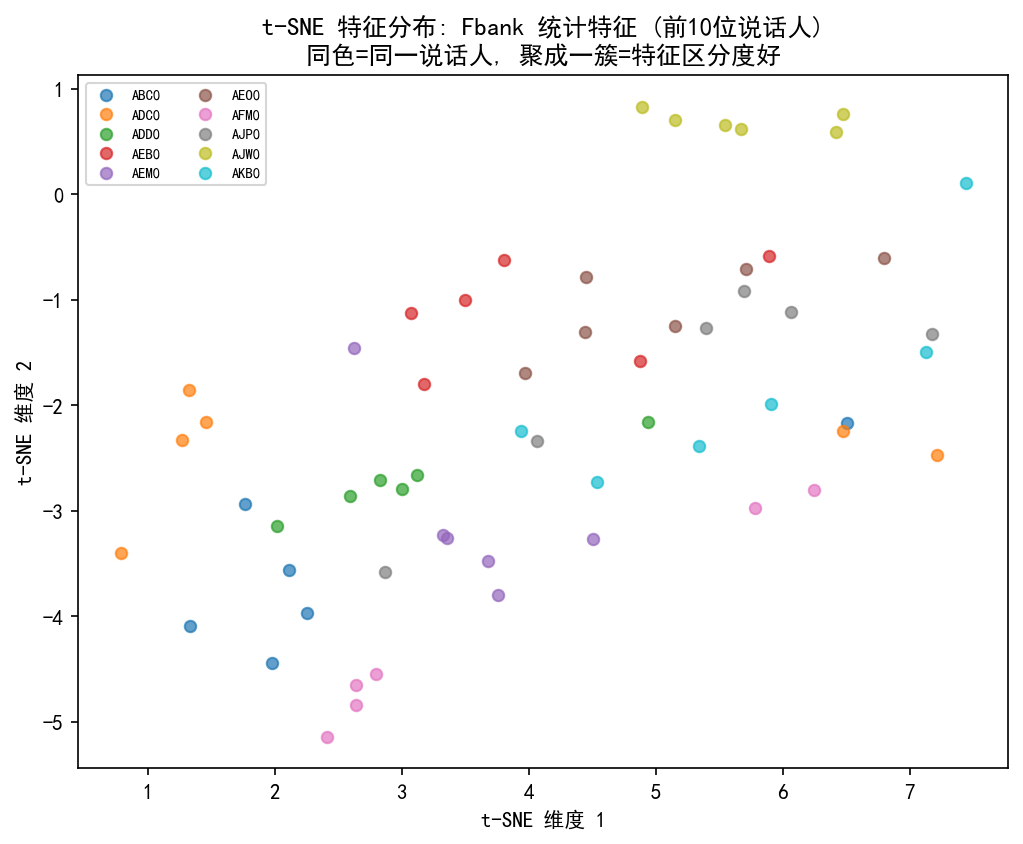

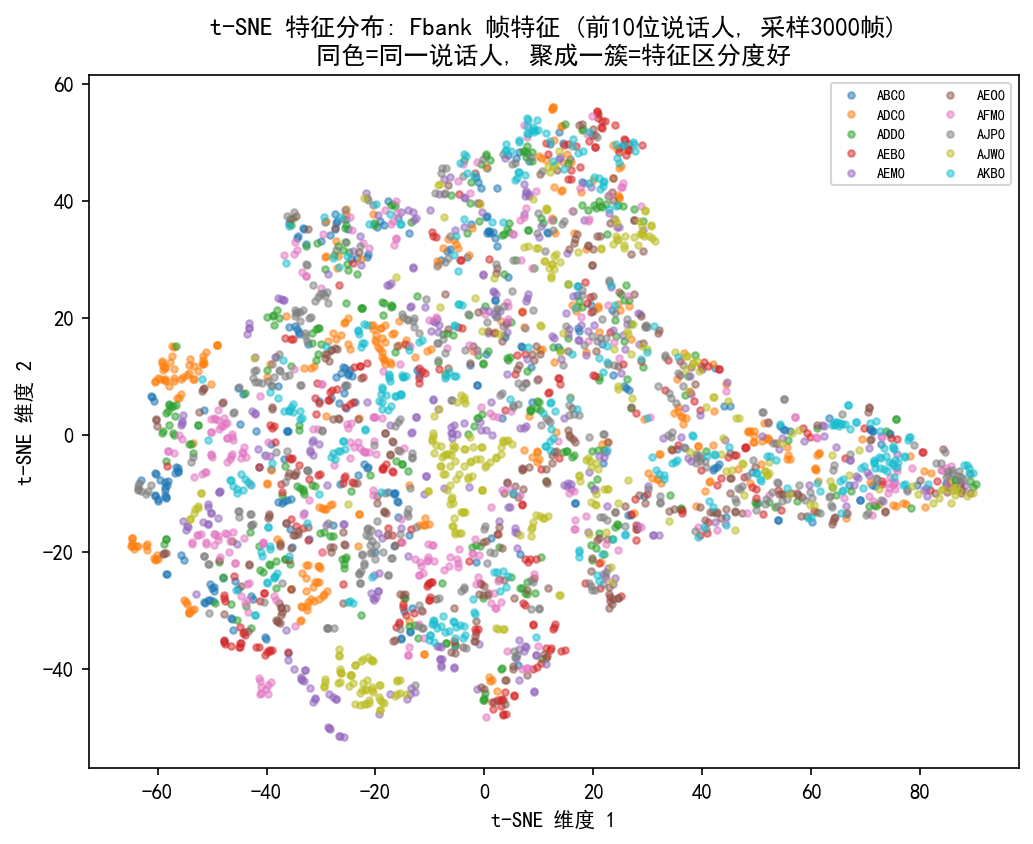

#### 6.3.2 Fbank + GMM 帧特征，不同高斯分量数

高斯分量数越多，准确率越高：n=1(29.87%) → n=16(80.41%)。每人约 570 帧，更多分量能更精细地拟合特征分布。

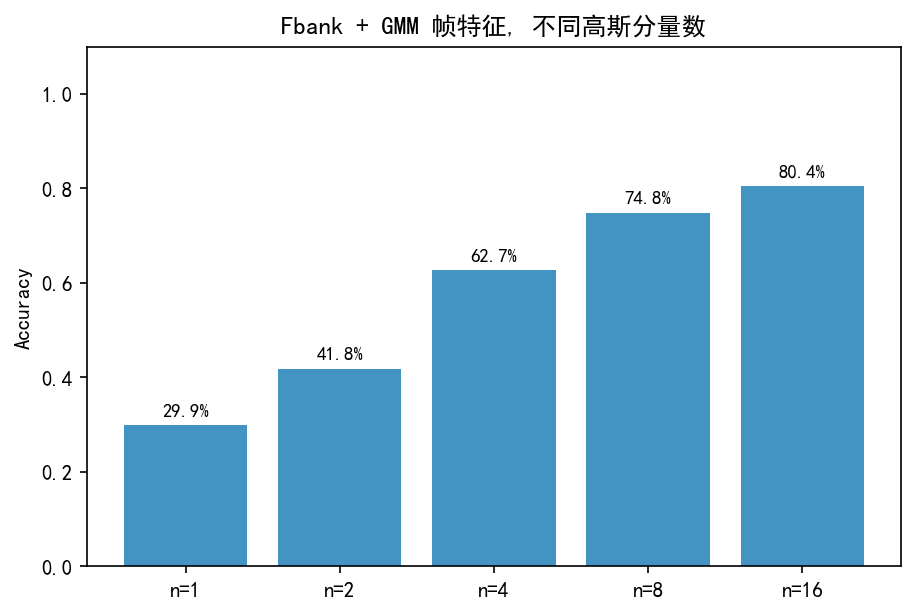

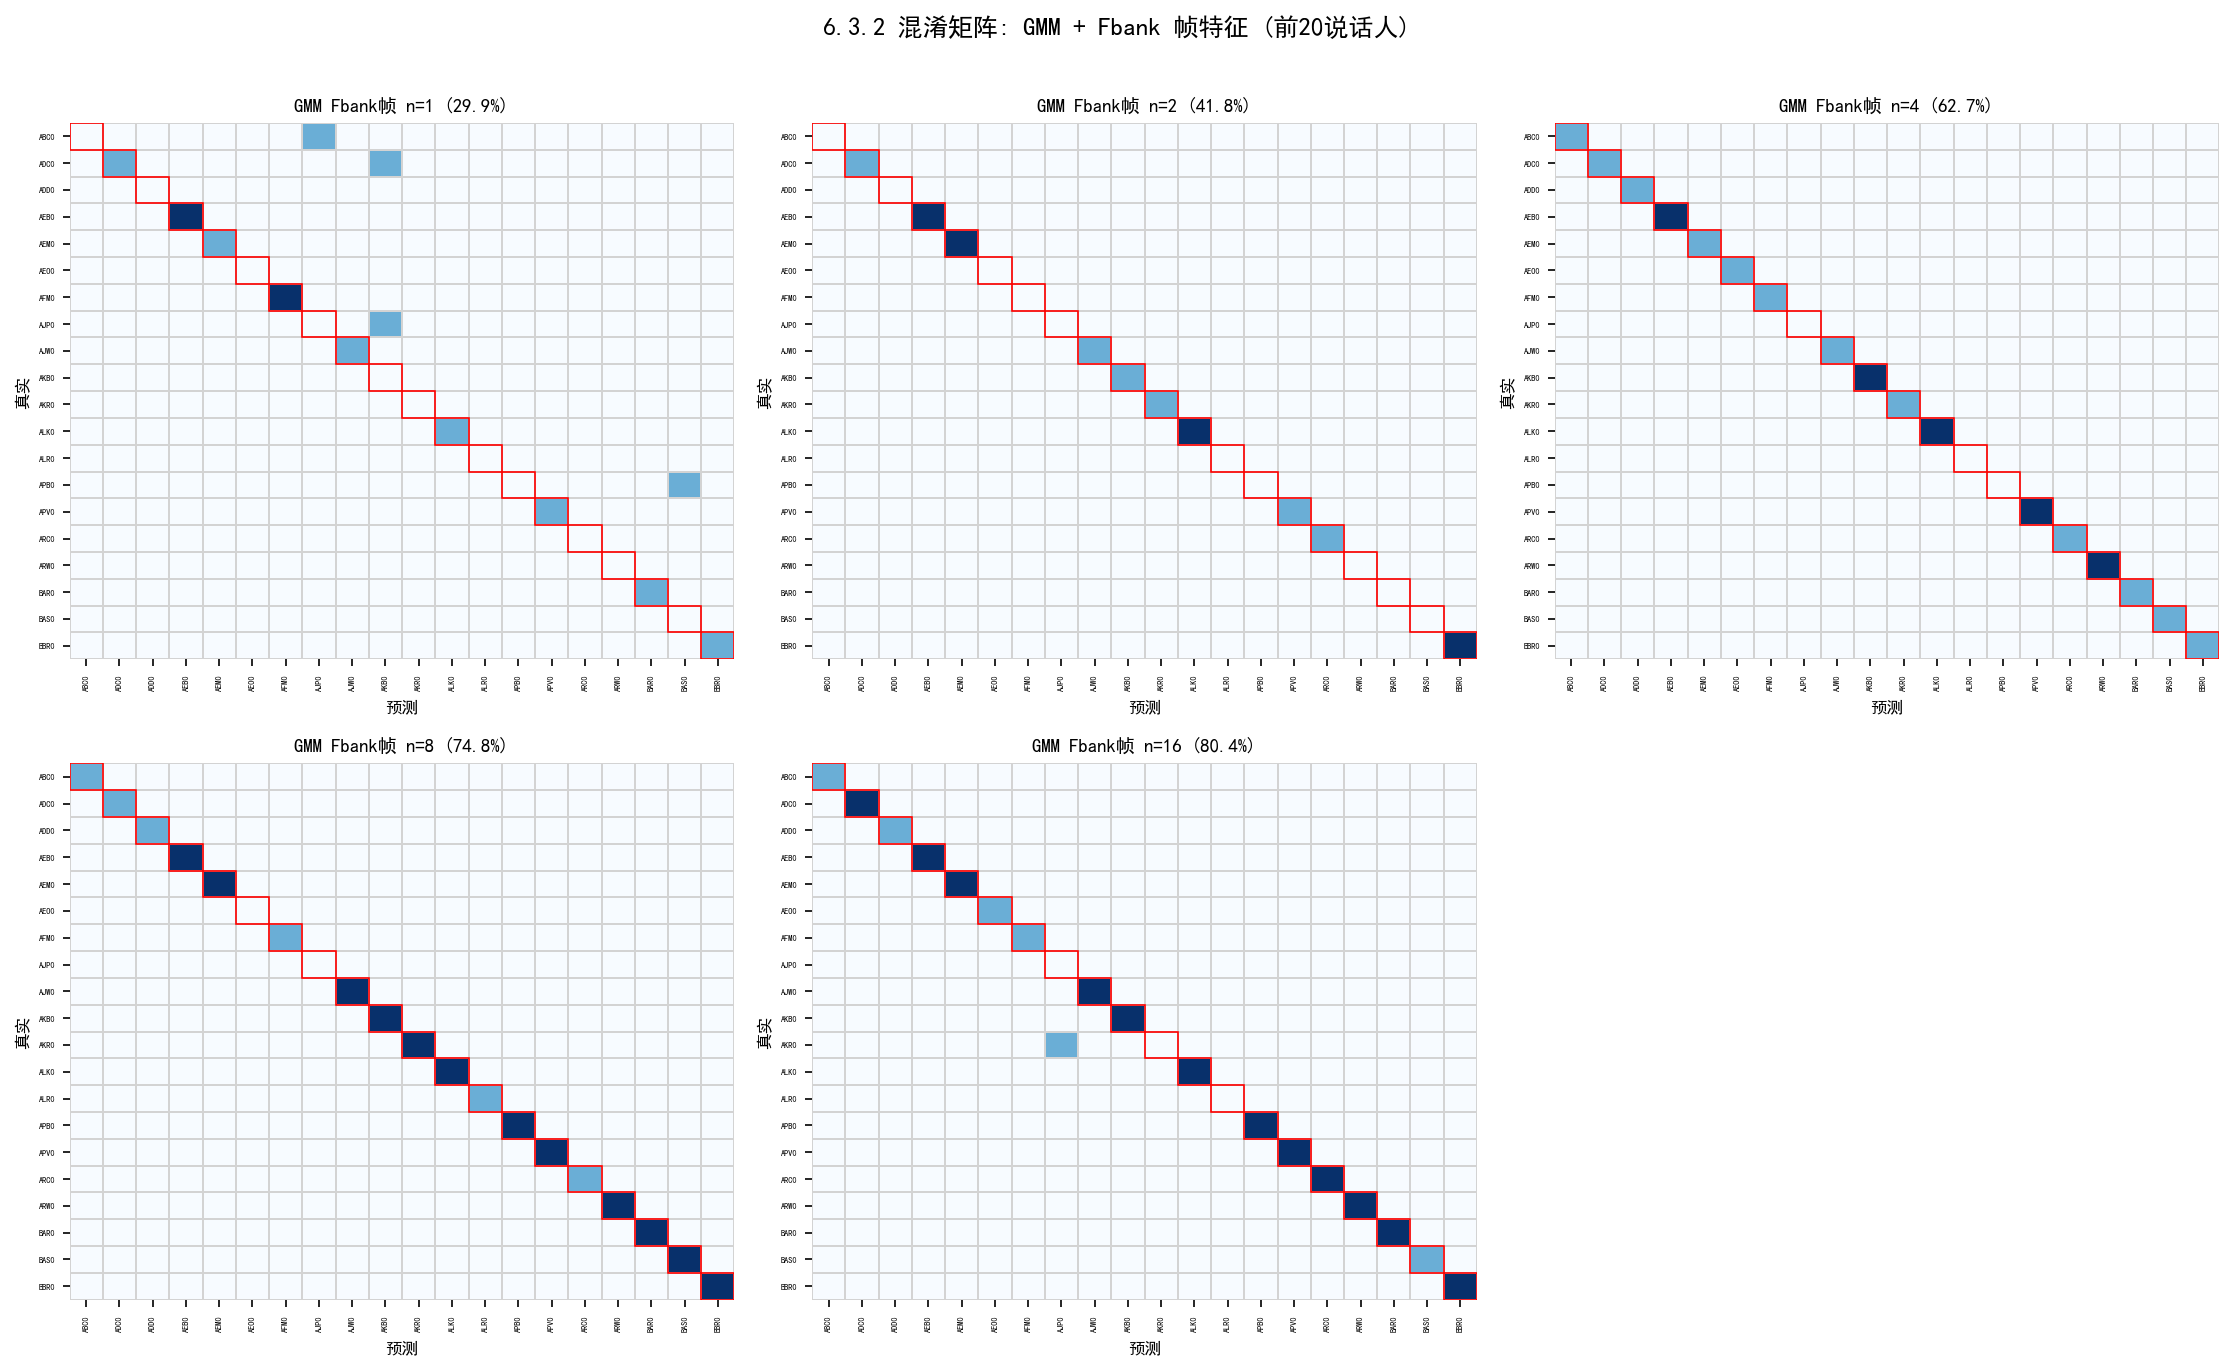

#### 6.3.3 Fbank + GMM 统计特征

统计特征下 n=1 效果最好(22.94%)，n 越大反而越差——每人仅 6 条样本，参数量 > 样本数据量，严重过拟合。

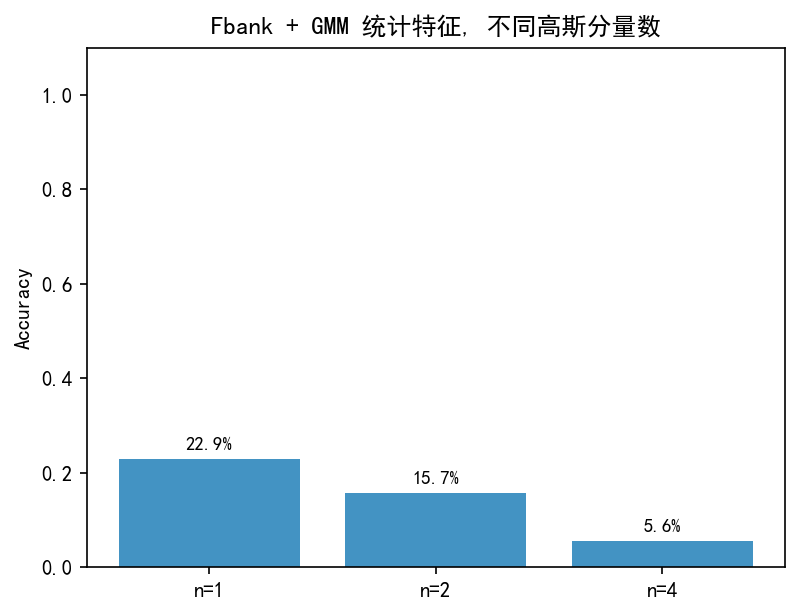

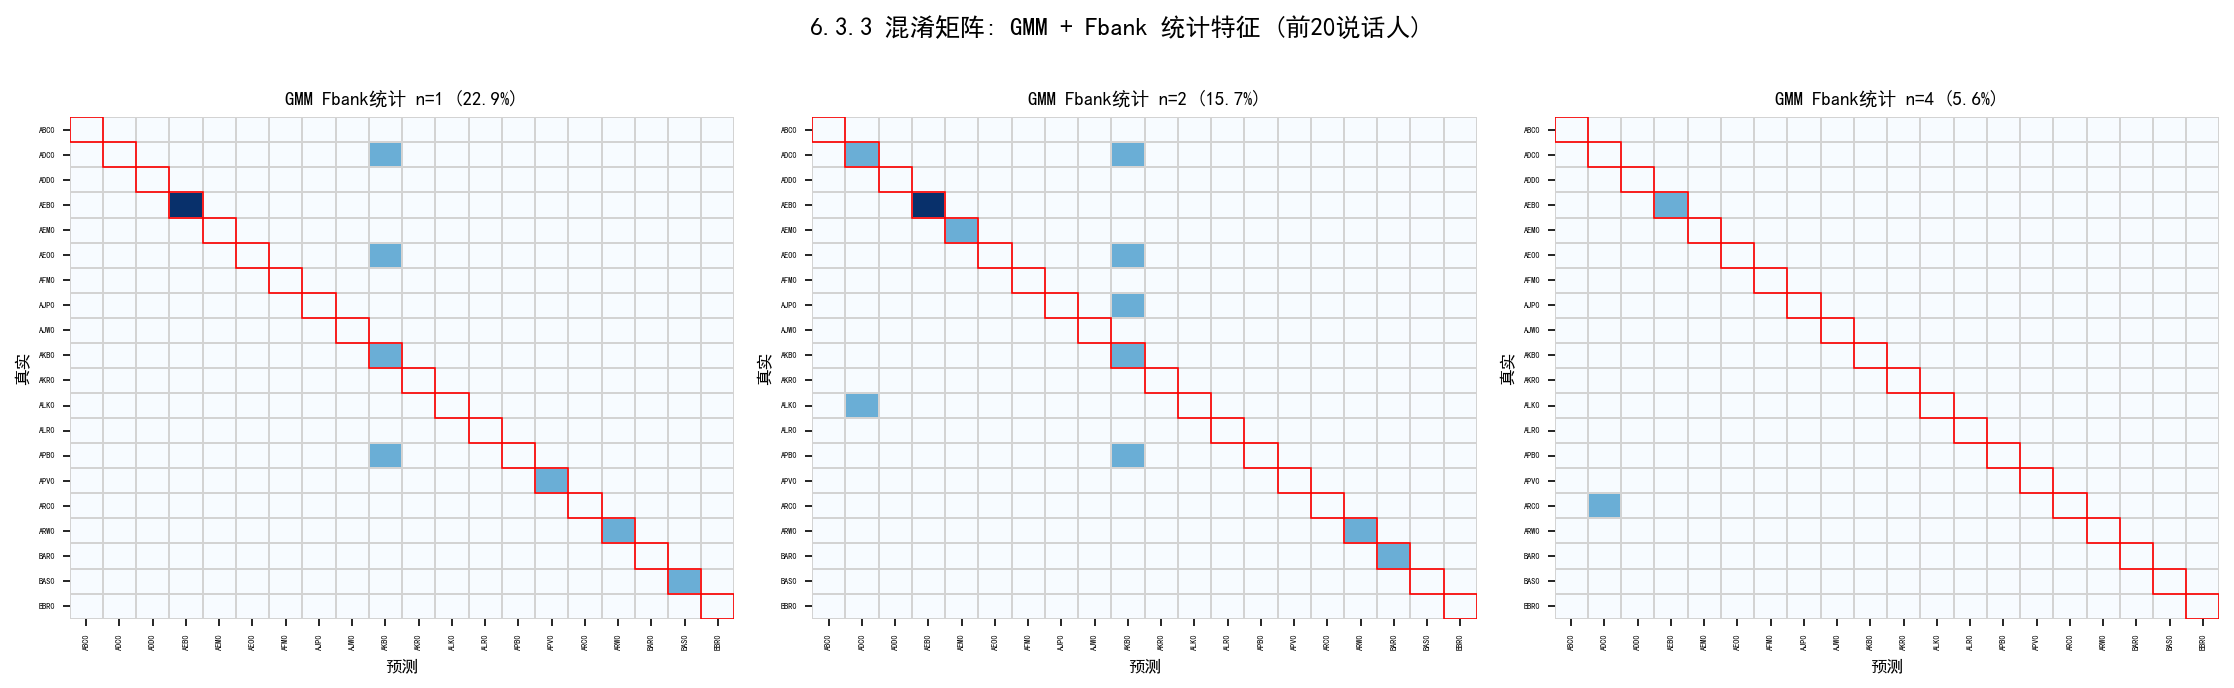

#### 6.3.4 SVM vs GMM（Fbank 统计特征）

对于 Fbank 统计特征，判别式模型 SVM(40.48%) 优于生成式模型 GMM(22.94%)。SVM 直接学习类间决策边界，对 Fbank 的相关维度有更强判别能力。另外可以看到 SVM 帧特征反而远不如统计特征(2.60%)，原因是 SVM 用 OvR 处理 462 分类时面临 570 正例 vs 26 万负例的极端类别不平衡。

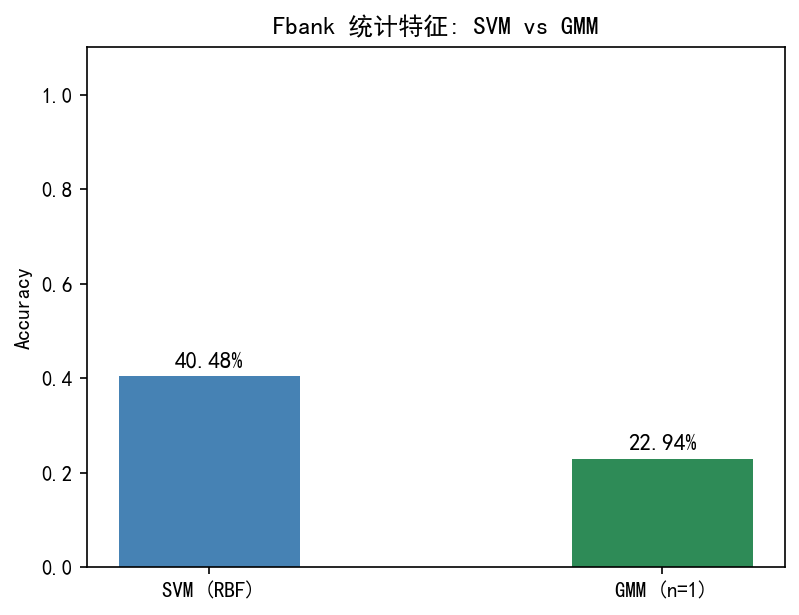

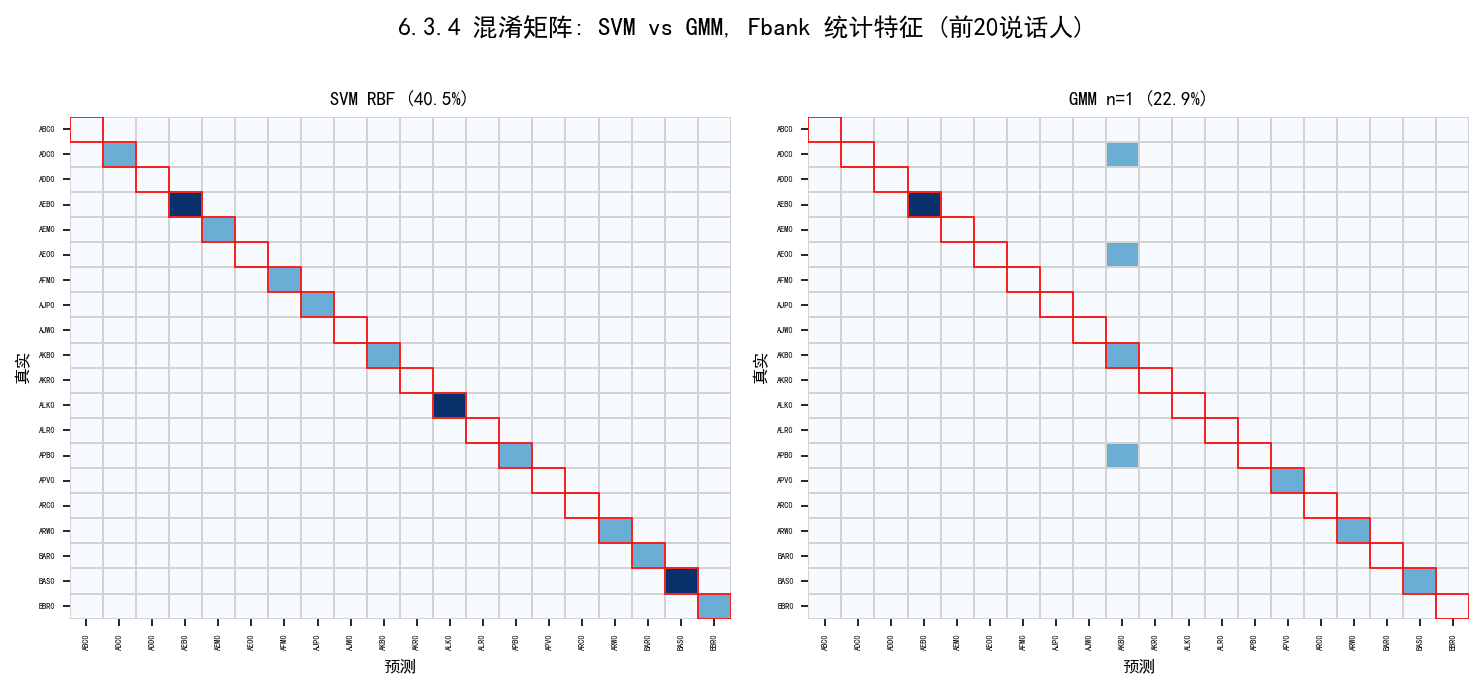

## 7. 结果讨论

总体而言，本实验验证了不同声学特征在说话人识别中的作用：MFCC 具有较强的频谱感知表达能力，LPCC 能够有效刻画声道结构特征，Fbank 保留了更原始的 Mel 频谱能量信息；而在模型选择上，GMM 相比 Softmax 和 SVM 更适合当前数据规模和任务设定。最终结果表明，传统统计模型在中小规模说话人识别任务中仍然具有很强的竞争力，尤其是在训练数据有限、类别数量较多的情况下，合理的特征设计和帧级概率建模往往比直接使用复杂判别式模型更加有效。具体如下：

### 7.1 MFCC+GMM

最开始采用统计特征来训练GMM，有一个很大的问题，每一个说话人只有6条训练样本，而每一条训练样本我们都只拿到了80维的特征（一个帧是40维，我们对同一个样本的所有帧在各个维度上算均值和房产），共计480个特征；而GMM也是各个分量在每个维度上都要算均值和方差，80维，一旦GMM分量比较大，参数量甚至大于输入特征量，模型效果肯定会不好  
对于使用统计特征的GMM，在高斯分量为4、2、1的情况下，测试的准确率分别为12.23%、36.26%、64.07%

而接下来我们改为使用帧特征，据我们前面的统计，一个句子的语音大概有150帧左右，每一帧都有一个40维的向量，每一位说话人又有6个训练样本，这样就有3万多特征，足以用来训练有多个分量的高斯混合模型（理论上，更多分量的高斯混合模型具有更好的鲁棒性，但是因为采用统计特征得到的特征量太少了，多一些高斯分量容易过拟合，效果反而不好）  
由实验结果我们知道，这个高斯混合模型的测试准确率达到了89.72%，已经很不错了。

### 7.2 LPCC-GMM/Softmax+LPCC-MFCC特征融合


本部分负责的是“基于 LPCC 的传统说话人识别方法研究”。与第一部分采用的 MFCC 路线不同，LPCC 来源于线性预测分析（LPC），更侧重描述语音的声道包络与共振峰结构；而 MFCC 更强调符合人耳听觉特性的频谱表示。因此，LPCC 路线可以视为与 MFCC 路线互补的另一类经典声学特征方案。

最初本实验采用的设置是 **LPCC + Softmax** ，但是效果较差，多次优化后的最优准确率仅为57%。核心原因在于本任务属于典型的“小样本、多类别”闭集识别问题：共有 462 位说话人，但每位说话人仅有 6 条训练语音。对于 Softmax 判别式分类器而言，需要直接学习 462 个类别之间的决策边界，而每类样本数量有限，容易出现类别边界学习不足、输出分布接近均匀的问题，导致整体识别率较低。

因此，本实验改用 **LPCC-GMM** 建模方式。该方法不再直接学习类别间边界，而是为每位说话人单独建立概率模型，学习其 LPCC 帧级特征分布。虽然每位说话人的句子数量较少，但每条语音可切分为大量帧级样本，因此实际可用于训练的特征点数量充足，更适合 GMM 这类生成式模型建模。

当前 LPCC-GMM 的完整流程为：首先对语音提取帧级 LPCC 特征，并利用能量 VAD 去除静音帧；随后拼接静态 LPCC、一阶差分（Delta）和二阶差分（Delta-Delta）特征，以同时描述静态声道结构与动态变化趋势；然后仅使用训练集统计全局均值和标准差，对训练集和测试集统一标准化；最后为每位说话人训练一个独立的 GMM。测试阶段，将一句测试语音的全部帧输入所有说话人模型，计算平均 log-likelihood，选择得分最高者作为最终识别结果。

实验结果表明，LPCC-GMM 在测试集上取得了 **96.75%** 的句级识别准确率，显著优于上一版 MLP 分类器方案，说明在当前少样本条件下，“帧级特征 + 生成式建模 + 句级似然判决”的整体思路是有效的，也验证了传统统计模型在中小规模说话人识别任务中仍具有较强竞争力。

进一步地，本实验比较了不同 GMM 分量数对性能的影响。结果显示，当分量数从 4 增加到 16 时，识别率持续提升；当继续增加到 24 时，准确率基本不再提升，甚至略有下降。这说明随着分量数增加，模型表达能力增强，能够更充分拟合说话人的多峰特征分布；但分量过多也会提高参数复杂度，在有限样本下带来轻微过拟合风险。因此，最终选择 **16 个高斯分量** 作为较优配置。

在特征消融实验中，仅使用静态 LPCC 时准确率已达到较高水平；加入一阶差分特征后，识别率进一步提升至最高值，说明动态变化信息能够补充静态声道特征，有助于区分不同说话人。继续加入二阶差分后，性能略有回落，说明过多动态特征可能引入噪声或冗余信息。因此，在本任务中，一阶动态特征的收益最明显。

此外，从混淆矩阵结果可以看出，大多数预测结果集中在主对角线位置，说明绝大多数说话人均能被正确识别，仅少数类别之间存在混淆。这些混淆通常来自声纹特征相近、语速接近或语音内容相似的说话人。与此同时，Top-1 与 Top-2 模型得分间隔分析显示：预测正确的样本通常具有更大的得分差值，而预测错误样本主要集中在低间隔区域，说明模型在出错时往往置信度较低，因此得分间隔可作为识别可信度的重要参考指标。

为了进一步探索特征互补性，本部分还尝试将 LPCC 与 MFCC 进行直接拼接融合。但实验结果显示，融合后准确率下降至约 **67%**，说明简单特征拼接并未带来收益。其主要原因在于特征维度显著上升，而每位说话人的训练样本有限，导致模型更容易过拟合；同时 LPCC 与 MFCC 在频谱信息上存在一定冗余，直接拼接可能增加噪声维度。随后加入 PCA 降维后，准确率进一步下降，说明无监督降维方法虽然保留总体方差，但未必保留最有利于区分说话人的判别信息。

综合来看，本实验说明：在当前 TIMIT 少样本、多类别说话人识别任务中，传统 **LPCC + GMM** 路线具有稳定且优异的性能；相比复杂神经网络结构，其优势在于参数规模小、训练稳定、对小数据集更友好。该结果也表明，在资源受限或样本不足的场景下，经典统计模型依然具有重要应用价值。


### 7.3 Fbank+GMM/SVM

本部分使用 **Fbank（Log Mel Filter Bank Energies）** 特征，分别结合 GMM 和 SVM 两种模型进行说话人识别，并与上述的 MFCC+GMM 实验结果进行对比分析。

**对比1：同模型(GMM)同特征类型(统计特征)，Fbank vs MFCC**

MFCC 在所有高斯分量数下都优于 Fbank（n=1: 64.07% vs 22.94%，n=2: 36.26% vs 15.69%，n=4: 12.23% vs 5.63%）。原因在于 MFCC 经 DCT 变换去除了各维度间的相关性，各维度更独立，更符合 GMM 对角协方差矩阵的假设；而 Fbank 保留了原始频谱能量，维度间相关性高，用 diag 协方差建模不够充分。

**对比2：同模型(GMM 帧特征 n=16)，Fbank vs MFCC**

MFCC(89.72%) 仍优于 Fbank(80.41%) 约 9 个百分点，但差距远小于统计特征（统计特征差距约 41 个百分点）。帧级别每人约 570 帧训练数据，足以支撑 n=16 的 GMM 充分拟合特征分布，两者均达到较高准确率，说明**帧特征+GMM**是有效的组合。

**对比3：同特征(Fbank 统计特征)，SVM vs GMM**

SVM(40.48%) > GMM(22.94%)。判别式模型直接学习类间决策边界，对 Fbank 的相关特征维度有更强的判别能力。但两者准确率都不高，根本原因是**每人仅 6 条样本**，统计特征信息量有限。

**SVM 帧特征为何不如统计特征**：SVM 用 OvR 策略处理 462 分类时，每个二分类器面对 570 正例 vs 26 万负例的极端类别不平衡，导致模型严重偏向负类；而 GMM 每人独立建模，更多帧 = 更好地拟合自身分布，不存在类别不平衡问题。因此**帧特征更适合 GMM，统计特征更适合 SVM**。

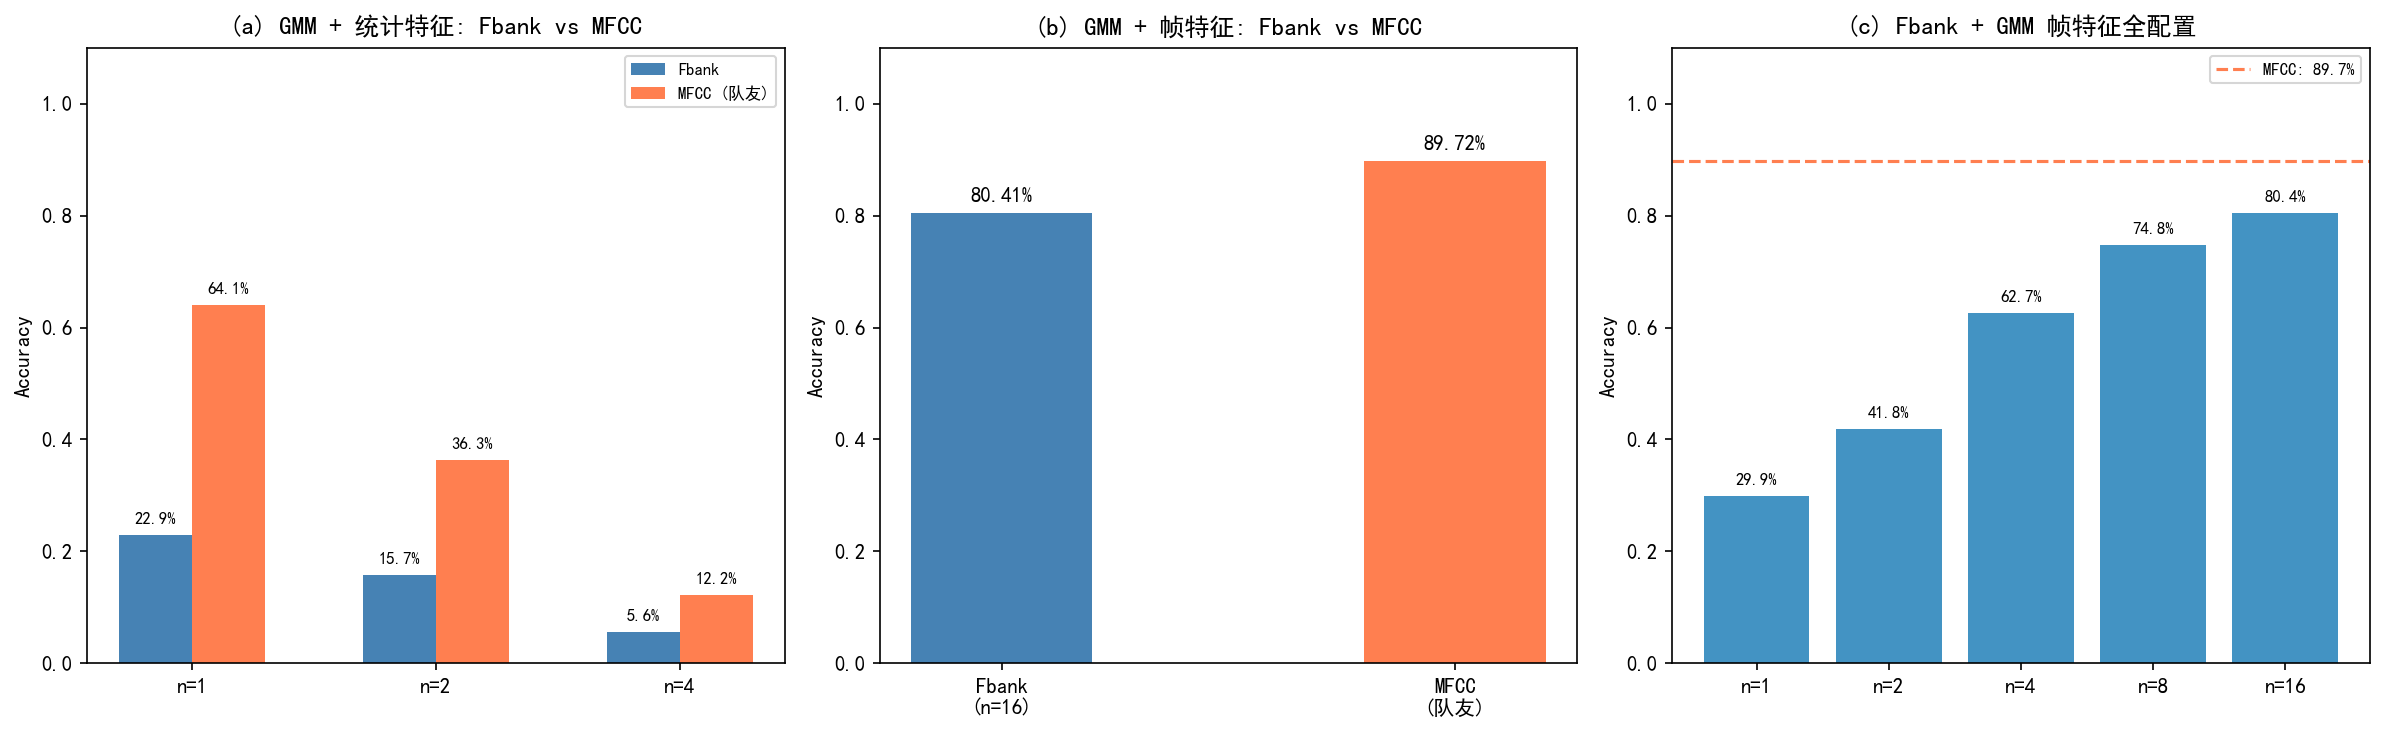